# Unified XAI Results Pipeline — Cloud Version

This notebook is the cloud-ready version of the unified XAI/CKA pipeline.

It is designed to run the full experiment in one place:

1. load selected RobustBench models,
2. generate adversarial examples,
3. compute ASR and transferability,
4. extract internal features,
5. compute layer-wise and cross-layer CKA,
6. connect CKA with adversarial transferability using correlation analysis,
7. save all CSV files and figures automatically.

## Main cloud idea

Only edit the **Configuration** section when you want to change models, add models, or change the run size.

For final cloud runs, keep one benchmark per run:

- CIFAR-10 + Linf,
- CIFAR-10 + L2,
- CIFAR-100 + Linf,
- ImageNet + Linf.

Do not mix datasets or threat models in one run.


## 1. Imports and global setup



In [ ]:
from pathlib import Path
from collections import OrderedDict
from itertools import combinations, permutations
import json
import math
import time
import warnings
import os
import random
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

try:
    from scipy.stats import pearsonr, spearmanr
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False
    print("scipy is not installed. Correlation p-values will not be available.")

try:
    from robustbench.utils import load_model
    from robustbench.data import load_cifar10
    try:
        from robustbench.data import load_cifar100
    except Exception:
        load_cifar100 = None
    try:
        from robustbench.data import load_imagenet
    except Exception:
        load_imagenet = None
    from robustbench.model_zoo.enums import ThreatModel
    HAS_ROBUSTBENCH = True
except Exception as e:
    HAS_ROBUSTBENCH = False
    print("RobustBench import failed:", repr(e))

try:
    from autoattack import AutoAttack
    HAS_AUTOATTACK = True
except Exception as e:
    HAS_AUTOATTACK = False
    print("AutoAttack import failed:", repr(e))

# =========================
# Device and cloud settings
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

    # Cloud GPU speed settings.
    # TF32 gives large speedups on Ampere/Ada/Hopper GPUs with very small numeric differences.
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    # Helps reduce CUDA memory fragmentation on long notebook runs.
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("Device:", DEVICE)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Total GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2),
        "GB"
    )
else:
    print("Warning: CUDA is not available. Final AutoAttack experiments should be run on a GPU server.")


Device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
# =========================
# Run mode settings
# =========================

# Default is "debug" to avoid accidentally running a heavy experiment.
# On HPC/Slurm, we can override it using:
# export RUN_MODE=cloud_final
RUN_MODE = os.getenv("RUN_MODE", "debug")   # options: "debug", "local", "cloud_final", "cloud_max"

if RUN_MODE == "debug":
    # Very small test run
    N_EXAMPLES = 50
    BATCH_SIZE = 32
    ATTACK_BATCH_SIZE = 16
    FEATURE_BATCH_SIZE = 32
    ATTACK_METHOD = "pgd"
    CKA_N_EXAMPLES = 50
    

elif RUN_MODE == "local":
    N_EXAMPLES = 100
    BATCH_SIZE = 16
    ATTACK_BATCH_SIZE = 8
    FEATURE_BATCH_SIZE = 16
    ATTACK_METHOD = "pgd"
    CKA_N_EXAMPLES = 100
    

elif RUN_MODE == "cloud_final":
    # Final HPC run
    N_EXAMPLES = 1000
    BATCH_SIZE = 128
    ATTACK_BATCH_SIZE = 64
    FEATURE_BATCH_SIZE = 128
    ATTACK_METHOD = "autoattack"
    CKA_N_EXAMPLES = 1000
    

elif RUN_MODE == "cloud_max":
    N_EXAMPLES = 5000
    BATCH_SIZE = 256
    ATTACK_BATCH_SIZE = 128
    FEATURE_BATCH_SIZE = 256
    ATTACK_METHOD = "autoattack"
    CKA_N_EXAMPLES = 2000
    

else:
    raise ValueError("RUN_MODE must be 'debug', 'local', 'cloud_final', or 'cloud_max'.")

print("Run mode:", RUN_MODE)
print("N_EXAMPLES:", N_EXAMPLES)
print("BATCH_SIZE:", BATCH_SIZE)
print("ATTACK_BATCH_SIZE:", ATTACK_BATCH_SIZE)
print("FEATURE_BATCH_SIZE:", FEATURE_BATCH_SIZE)
print("ATTACK_METHOD:", ATTACK_METHOD)
print("CKA_N_EXAMPLES:", CKA_N_EXAMPLES)


## 2. Configuration

This is the most important section.

To change or add models later, edit only `MODEL_CONFIGS`. All selected models from the provided tables are now listed there, and `SELECTED_BENCHMARK` controls which group runs.

### Rules

1. Run **one benchmark at a time**.
2. Do not mix CIFAR-10, CIFAR-100, and ImageNet in the same run.
3. Do not mix `Linf` and `L2` models in the same run.
4. Use the exact RobustBench model name in `robustbench_model`.
5. Use a short readable name in `model` for plots and CSV files.
6. Use `enabled=True` for models included in the run.
7. Use `enabled=False` to keep a model in the list but skip it temporarily.

### Model dictionary format

```python
{
    "model": "ShortNameForPlots",
    "robustbench_model": "ExactRobustBenchModelID",
    "architecture": "ResNet / WideResNet / ConvNeXt / etc.",
    "training_type": "standard / adversarial_training / fast_adversarial_training / etc.",
    "dataset": "cifar10",
    "threat_model": "Linf",
    "epsilon": 8/255,
    "enabled": True,
    "layers": None,
}
```

If automatic layer selection is not good for a model, replace `layers=None` with a list of exact layer names.


In [ ]:
# ---------------------------------------------------------------------
# Project root
# ---------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()

# ---------------------------------------------------------------------
# Benchmark selection
# ---------------------------------------------------------------------
# Supported values:
# - "cifar10_linf"
# - "cifar10_l2"
# - "cifar100_linf"
# - "imagenet_linf"
#
# The notebook will automatically select only the models that belong
# to this benchmark.
SELECTED_BENCHMARK = os.getenv("SELECTED_BENCHMARK", "cifar10_linf")

BENCHMARK_SETTINGS = {
    "cifar10_linf": {
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
    },
    "cifar10_l2": {
        "dataset": "cifar10",
        "threat_model": "L2",
        "epsilon": 0.5,
    },
    "cifar100_linf": {
        "dataset": "cifar100",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
    },
    "imagenet_linf": {
        "dataset": "imagenet",
        "threat_model": "Linf",
        "epsilon": 4 / 255,
    },
}

if SELECTED_BENCHMARK not in BENCHMARK_SETTINGS:
    raise ValueError(f"Unknown SELECTED_BENCHMARK: {SELECTED_BENCHMARK}")

DATASET = BENCHMARK_SETTINGS[SELECTED_BENCHMARK]["dataset"]
THREAT_MODEL_NAME = BENCHMARK_SETTINGS[SELECTED_BENCHMARK]["threat_model"]
EPS = BENCHMARK_SETTINGS[SELECTED_BENCHMARK]["epsilon"]

# ---------------------------------------------------------------------
# Output folders
# ---------------------------------------------------------------------
# Each benchmark/run mode gets its own folder so results are not overwritten.
SAVED_DIR = PROJECT_ROOT / "saved_outputs_cloud" / SELECTED_BENCHMARK / RUN_MODE
FIG_DIR = SAVED_DIR / "figures"

SAVED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if HAS_ROBUSTBENCH:
    THREAT_MODEL = getattr(ThreatModel, THREAT_MODEL_NAME)
else:
    THREAT_MODEL = None

# ---------------------------------------------------------------------
# Attack settings
# ---------------------------------------------------------------------
# PGD is used for debug/local testing.
# AutoAttack is used for final standardized evaluation.
PGD_STEPS = 10
PGD_ALPHA = 2 / 255
AUTOATTACK_VERSION = "standard"  # options: standard, plus, rand

# ---------------------------------------------------------------------
# CKA  settings
# ---------------------------------------------------------------------
MAX_CKA_LAYERS = 6
CKA_PAIR_MODE = "unique"   # unique = A-B once, ordered = A->B and B->A
RUN_TRANSFERABLE_CKA = False
MIN_TRANSFER_GROUP_SIZE = 2

# ---------------------------------------------------------------------
# RobustBench model-name helper
# ---------------------------------------------------------------------
def get_available_robustbench_names(dataset=DATASET, threat_model=THREAT_MODEL_NAME):
    """
    Return exact RobustBench model IDs for the selected dataset/threat model.

    This version supports RobustBench installations where model_dicts uses
    enum dataset keys, for example BenchmarkDataset.cifar_10 instead of
    the string 'cifar10'.
    """
    if not HAS_ROBUSTBENCH:
        return []

    try:
        from robustbench.model_zoo import model_dicts
        from robustbench.model_zoo.enums import ThreatModel

        # Find dataset key safely.
        dataset_key = None
        for key in model_dicts.keys():
            if getattr(key, "value", None) == dataset:
                dataset_key = key
                break

        if dataset_key is None:
            print("Dataset key not found:", dataset)
            print("Available dataset keys:", list(model_dicts.keys()))
            return []

        # Find threat-model key safely.
        if isinstance(threat_model, str):
            threat_key = getattr(ThreatModel, threat_model)
        else:
            threat_key = threat_model

        return list(model_dicts[dataset_key][threat_key].keys())

    except Exception as e:
        print("Could not read RobustBench model list:", repr(e))
        return []


def show_available_robustbench_models(dataset=DATASET, threat_model=THREAT_MODEL_NAME, limit=None):
    """Print exact RobustBench model IDs for the selected dataset/threat model."""
    names = get_available_robustbench_names(dataset, threat_model)

    if not names:
        print("Could not list RobustBench models. Check RobustBench installation/version.")
        return []

    shown = names if limit is None else names[:limit]

    print(f"Available RobustBench models for {dataset} / {threat_model}:")
    for name in shown:
        print("-", name)

    print(f"Total available: {len(names)}")
    return names


# Uncomment this if a model name fails and you need to copy the exact RobustBench ID.
# available_names = show_available_robustbench_models(limit=120)

# ---------------------------------------------------------------------
# Model registry: selected models from the provided tables
# ---------------------------------------------------------------------
# Important:
# - All selected models from the provided tables are listed here.
# - The notebook runs ONE benchmark at a time using SELECTED_BENCHMARK.
# - Models from other datasets/threat models stay in the registry but are filtered out automatically.
# - If a model is not available in the installed RobustBench version, it will be skipped and reported.

MODEL_CONFIGS = [
    # ================================================================
    # Table 2 + Table 6: CIFAR-10 / Linf / epsilon = 8/255
    # ================================================================
    {
        "model": "Wang2023Better_WRN70_16",
        "robustbench_model": "Wang2023Better_WRN-70-16",
        "architecture": "WRN-70-16",
        "training_type": "adversarial_training_diffusion_data",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Wang2023Better_WRN28_10",
        "robustbench_model": "Wang2023Better_WRN-28-10",
        "architecture": "WRN-28-10",
        "training_type": "adversarial_training_diffusion_data",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Rebuffi2021Fixing_70_16_cutmix_extra",
        "robustbench_model": "Rebuffi2021Fixing_70_16_cutmix_extra",
        "architecture": "WRN-70-16",
        "training_type": "adversarial_training_extra_data_cutmix",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Gowal2021Improving_28_10_ddpm_100m",
        "robustbench_model": "Gowal2021Improving_28_10_ddpm_100m",
        "architecture": "WRN-28-10",
        "training_type": "adversarial_training_ddpm_100m",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Rade2021Helper_extra",
        "robustbench_model": "Rade2021Helper_extra",
        "architecture": "WRN-34-10",
        "training_type": "helper_based_adversarial_training_extra_data",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Sehwag2021Proxy_R18",
        "robustbench_model": "Sehwag2021Proxy_R18",
        "architecture": "ResNet-18",
        "training_type": "proxy_distribution_adversarial_training",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Bartoldson2024Adversarial_WRN94_16",
        "robustbench_model": "Bartoldson2024Adversarial_WRN-94-16",
        "architecture": "WRN-94-16",
        "training_type": "scaling_law_human_alignment_sota",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Amini2024MeanSparse_S_WRN94_16",
        "robustbench_model": "Amini2024MeanSparse_S-WRN-94-16",
        "architecture": "MeanSparse-WRN-94-16",
        "training_type": "meansparse_post_training_enhancement",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Peng2023Robust",
        "robustbench_model": "Peng2023Robust",
        "architecture": "RaWideResNet-70-16",
        "training_type": "architecture_optimized_adversarial_training",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Bai2024MixedNUTS",
        "robustbench_model": "Bai2024MixedNUTS",
        "architecture": "ResNet-152 + WRN-70-16 ensemble",
        "training_type": "ensemble_mixed_classifier",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        # Correct name is ResNest152, not ResNet152.
        "model": "Sehwag2021Proxy_ResNest152",
        "robustbench_model": "Sehwag2021Proxy_ResNest152",
        "architecture": "ResNest-152",
        "training_type": "proxy_distribution_adversarial_training",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Gowal2021Improving_R18_ddpm_100m",
        "robustbench_model": "Gowal2021Improving_R18_ddpm_100m",
        "architecture": "PreActResNet-18",
        "training_type": "adversarial_training_ddpm_100m_small_backbone",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "Debenedetti2022Light_XCiT_L12",
        "robustbench_model": "Debenedetti2022Light_XCiT-L12",
        "architecture": "XCiT-L12",
        "training_type": "attention_based_model",
        "dataset": "cifar10",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },

    # ================================================================
    # Table 3: CIFAR-10 / L2 / epsilon = 0.5
    # ================================================================
    {
        "model": "L2_Wang2023Better_WRN70_16",
        "robustbench_model": "Wang2023Better_WRN-70-16",
        "architecture": "WRN-70-16",
        "training_type": "adversarial_training_diffusion_data",
        "dataset": "cifar10",
        "threat_model": "L2",
        "epsilon": 0.5,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "L2_Wang2023Better_WRN28_10",
        "robustbench_model": "Wang2023Better_WRN-28-10",
        "architecture": "WRN-28-10",
        "training_type": "adversarial_training_diffusion_data",
        "dataset": "cifar10",
        "threat_model": "L2",
        "epsilon": 0.5,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "L2_Rebuffi2021Fixing_70_16_cutmix_extra",
        "robustbench_model": "Rebuffi2021Fixing_70_16_cutmix_extra",
        "architecture": "WRN-70-16",
        "training_type": "adversarial_training_extra_data_cutmix",
        "dataset": "cifar10",
        "threat_model": "L2",
        "epsilon": 0.5,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "L2_Sehwag2021Proxy_R18",
        "robustbench_model": "Sehwag2021Proxy_R18",
        "architecture": "ResNet-18",
        "training_type": "proxy_distribution_adversarial_training",
        "dataset": "cifar10",
        "threat_model": "L2",
        "epsilon": 0.5,
        "enabled": True,
        "layers": None,
    },

    # ================================================================
    # Table 4: CIFAR-100 / Linf / epsilon = 8/255
    # ================================================================
    {
        "model": "C100_Wang2023Better_WRN70_16",
        "robustbench_model": "Wang2023Better_WRN-70-16",
        "architecture": "WRN-70-16",
        "training_type": "adversarial_training_diffusion_data",
        "dataset": "cifar100",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "C100_Wang2023Better_WRN28_10",
        "robustbench_model": "Wang2023Better_WRN-28-10",
        "architecture": "WRN-28-10",
        "training_type": "adversarial_training_diffusion_data",
        "dataset": "cifar100",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "C100_Rebuffi2021Fixing_70_16_cutmix_ddpm",
        "robustbench_model": "Rebuffi2021Fixing_70_16_cutmix_ddpm",
        "architecture": "WRN-70-16",
        "training_type": "adversarial_training_cutmix_ddpm",
        "dataset": "cifar100",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "C100_Addepalli2022Efficient_RN18",
        "robustbench_model": "Addepalli2022Efficient_RN18",
        "architecture": "ResNet-18",
        "training_type": "efficient_adversarial_training",
        "dataset": "cifar100",
        "threat_model": "Linf",
        "epsilon": 8 / 255,
        "enabled": True,
        "layers": None,
    },

    # ================================================================
    # Table 5: ImageNet / Linf / epsilon = 4/255
    # ================================================================
    {
        "model": "ImageNet_Salman2020Do_50_2",
        "robustbench_model": "Salman2020Do_50_2",
        "architecture": "WRN-50-2",
        "training_type": "adversarial_training_imagenet",
        "dataset": "imagenet",
        "threat_model": "Linf",
        "epsilon": 4 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "ImageNet_Salman2020Do_R50",
        "robustbench_model": "Salman2020Do_R50",
        "architecture": "ResNet-50",
        "training_type": "adversarial_training_imagenet",
        "dataset": "imagenet",
        "threat_model": "Linf",
        "epsilon": 4 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "ImageNet_Engstrom2019Robustness",
        "robustbench_model": "Engstrom2019Robustness",
        "architecture": "ResNet-50",
        "training_type": "adversarial_training_imagenet",
        "dataset": "imagenet",
        "threat_model": "Linf",
        "epsilon": 4 / 255,
        "enabled": True,
        "layers": None,
    },
    {
        "model": "ImageNet_Salman2020Do_R18",
        "robustbench_model": "Salman2020Do_R18",
        "architecture": "ResNet-18",
        "training_type": "adversarial_training_imagenet",
        "dataset": "imagenet",
        "threat_model": "Linf",
        "epsilon": 4 / 255,
        "enabled": True,
        "layers": None,
    },
]

# ---------------------------------------------------------------------
# Select active models for this run
# ---------------------------------------------------------------------
ACTIVE_MODEL_CONFIGS = []

for cfg in MODEL_CONFIGS:
    if not cfg.get("enabled", True):
        continue

    if cfg["dataset"] != DATASET:
        continue

    if cfg["threat_model"] != THREAT_MODEL_NAME:
        continue

    ACTIVE_MODEL_CONFIGS.append(cfg)

# ---------------------------------------------------------------------
# RobustBench availability check
# ---------------------------------------------------------------------
# This prevents the whole notebook from failing if the installed
# RobustBench version does not include one of the selected model IDs.
available_names = get_available_robustbench_names(DATASET, THREAT_MODEL_NAME)

MISSING_MODEL_CONFIGS = []

if available_names:
    available_set = set(available_names)
    checked_active = []

    for cfg in ACTIVE_MODEL_CONFIGS:
        if cfg["robustbench_model"] in available_set:
            checked_active.append(cfg)
        else:
            MISSING_MODEL_CONFIGS.append(cfg)

    ACTIVE_MODEL_CONFIGS = checked_active

if MISSING_MODEL_CONFIGS:
    print("WARNING: these selected models were not found in your installed RobustBench version and were skipped:")

    for cfg in MISSING_MODEL_CONFIGS:
        print("-", cfg["model"], "| RobustBench ID:", cfg["robustbench_model"])

    print("Run show_available_robustbench_models() to check the exact model IDs on your server.")

if len(ACTIVE_MODEL_CONFIGS) < 2:
    raise ValueError(
        "At least two available enabled models are required for transferability and CKA analysis. "
        "Check SELECTED_BENCHMARK and RobustBench model IDs."
    )

MODEL_CONFIGS = ACTIVE_MODEL_CONFIGS
MODEL_NAMES = [cfg["model"] for cfg in MODEL_CONFIGS]

# ---------------------------------------------------------------------
# Safety check: one dataset, one threat model, one epsilon per run
# ---------------------------------------------------------------------
datasets = sorted(set(cfg["dataset"] for cfg in MODEL_CONFIGS))
threat_models = sorted(set(cfg["threat_model"] for cfg in MODEL_CONFIGS))
epsilons = sorted(set(float(cfg["epsilon"]) for cfg in MODEL_CONFIGS))

print("Selected benchmark:", SELECTED_BENCHMARK)
print("Dataset:", DATASET)
print("Threat model:", THREAT_MODEL_NAME)
print("Epsilon:", EPS)
print("Datasets in active config:", datasets)
print("Threat models in active config:", threat_models)
print("Epsilons in active config:", epsilons)

if len(datasets) > 1:
    raise ValueError("Do not mix datasets in one run.")

if len(threat_models) > 1:
    raise ValueError("Do not mix threat models in one run.")

if len(epsilons) > 1:
    raise ValueError("Do not mix epsilon values in one run.")

# ---------------------------------------------------------------------
# Save selected model info
# ---------------------------------------------------------------------
model_info_df = pd.DataFrame([
    {k: v for k, v in cfg.items() if k != "layers"}
    for cfg in MODEL_CONFIGS
])

model_info_df.to_csv(SAVED_DIR / "model_info.csv", index=False)

if MISSING_MODEL_CONFIGS:
    missing_model_info_df = pd.DataFrame([
        {k: v for k, v in cfg.items() if k != "layers"}
        for cfg in MISSING_MODEL_CONFIGS
    ])

    missing_model_info_df.to_csv(SAVED_DIR / "missing_or_unavailable_models.csv", index=False)

display(model_info_df)

print("Selected models:", MODEL_NAMES)
print("Number of selected models:", len(MODEL_NAMES))
print("Saved outputs:", SAVED_DIR.resolve())
print("Saved figures:", FIG_DIR.resolve())

,model,architecture,training_type,enabled
0,Standard,ResNet,standard,True
1,Engstrom2019Robustness,ResNet,adversarial_training,True
2,Wong2020Fast,WideResNet,fast_adversarial_training,True
3,Rice2020Overfitting,WideResNet,adversarial_training_robust_overfitting,True


Selected models: ['Standard', 'Engstrom2019Robustness', 'Wong2020Fast', 'Rice2020Overfitting']
Saved outputs: C:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs
Saved figures: C:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures


### Cloud running order

Recommended workflow:

1. Run once with `RUN_MODE = "debug"` and 2–3 models.
2. If the pipeline finishes, switch to `RUN_MODE = "cloud_final"`.
3. Add the remaining selected models one by one in `MODEL_CONFIGS`.
4. If the server has enough GPU memory and time, use `RUN_MODE = "cloud_max"`.

If you get a CUDA out-of-memory error, reduce these values first:

1. `ATTACK_BATCH_SIZE`,
2. `FEATURE_BATCH_SIZE`,
3. `BATCH_SIZE`,
4. `CKA_N_EXAMPLES`.


### Running all benchmark groups on the cloud

This notebook still runs **one benchmark per execution**.  
To run all selected model groups safely, launch the notebook four times with different environment variables:

1. `cifar10_linf`
2. `cifar10_l2`
3. `cifar100_linf`
4. `imagenet_linf`

Each run will save results in a separate folder:

```text
saved_outputs_cloud/<benchmark>/<run_mode>/
```

This avoids mixing datasets, threat models, or epsilon values in the same transferability/CKA analysis.


In [ ]:
# =========================
# Batch-run command helper
# =========================
# This cell prints cloud commands for running all benchmark groups separately.
# It does NOT execute them automatically inside the notebook.

BENCHMARK_RUN_PLAN = [
    "cifar10_linf",
    "cifar10_l2",
    "cifar100_linf",
    "imagenet_linf",
]

NOTEBOOK_FILE = "unified_xai_results_pipeline_cka_cloud_batch.ipynb"

print("Run these commands from the terminal on the cloud server:")
print()

for benchmark in BENCHMARK_RUN_PLAN:
    output_name = f"executed_{benchmark}_cloud_final.ipynb"
    cmd = (
        f"SELECTED_BENCHMARK={benchmark} RUN_MODE=cloud_final "
        f"jupyter nbconvert --to notebook --execute {NOTEBOOK_FILE} "
        f"--output {output_name} "
        f"--ExecutePreprocessor.timeout=-1"
    )
    print(cmd)
    print()


In [ ]:
# =========================
# Optional: create a shell script to run all benchmarks
# =========================
# Run this cell once, then execute this in the terminal:
# bash run_all_benchmarks_cloud.sh

script = r'''#!/usr/bin/env bash
set -e

NOTEBOOK="unified_xai_results_pipeline_cka_cloud_batch.ipynb"
RUN_MODE="${RUN_MODE:-cloud_final}"

for BENCHMARK in cifar10_linf cifar10_l2 cifar100_linf imagenet_linf
do
  echo "============================================================"
  echo "Running benchmark: ${BENCHMARK} | mode: ${RUN_MODE}"
  echo "============================================================"

  SELECTED_BENCHMARK="${BENCHMARK}" RUN_MODE="${RUN_MODE}" \
  jupyter nbconvert --to notebook --execute "${NOTEBOOK}" \
    --output "executed_${BENCHMARK}_${RUN_MODE}.ipynb" \
    --ExecutePreprocessor.timeout=-1
done

echo "All benchmark runs finished."
echo "Results are saved under saved_outputs_cloud/<benchmark>/<run_mode>/"
'''

script_path = PROJECT_ROOT / "run_all_benchmarks_cloud.sh"
script_path.write_text(script)
print("Created:", script_path.resolve())
print("To run all benchmarks:")
print("bash run_all_benchmarks_cloud.sh")
print()
print("To run debug mode instead:")
print("RUN_MODE=debug bash run_all_benchmarks_cloud.sh")


## 3. Utility functions

In [65]:
def safe_model_name(name: str) -> str:
    return name.replace("/", "_").replace(" ", "_").replace(".", "_").replace("-", "_")


def get_pair_iterator(names, mode="unique"):
    """Return model pairs.
    - unique: A-B once only, good for CKA plots.
    - ordered: A->B and B->A, needed when direction matters.
    """
    if mode == "unique":
        return list(combinations(names, 2))
    if mode == "ordered":
        return list(permutations(names, 2))
    raise ValueError("mode must be 'unique' or 'ordered'")


def empty_cuda_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def add_pair_type_from_metadata(source_model, target_model):
    """Return pair type using the global model_metadata/config_by_name dictionary."""
    meta = globals().get("model_metadata", globals().get("config_by_name", {}))
    src_cfg = meta.get(source_model, {})
    tgt_cfg = meta.get(target_model, {})

    def is_standard(cfg):
        return str(cfg.get("training_type", "")).lower() == "standard"

    s_std = is_standard(src_cfg)
    t_std = is_standard(tgt_cfg)
    if s_std and t_std:
        return "standard_standard"
    if (not s_std) and (not t_std):
        return "robust_robust"
    return "standard_robust"


## 4. Load CIFAR-10 subset

In [66]:
if not HAS_ROBUSTBENCH:
    raise ImportError("RobustBench is required to load datasets and RobustBench models.")


def load_dataset_subset(dataset, n_examples, data_dir="./data"):
    """Load the clean evaluation subset for the selected benchmark."""
    dataset = dataset.lower()

    if dataset == "cifar10":
        return load_cifar10(n_examples=n_examples, data_dir=data_dir)

    if dataset == "cifar100":
        if load_cifar100 is None:
            raise ImportError("load_cifar100 is not available in this RobustBench installation.")
        return load_cifar100(n_examples=n_examples, data_dir=data_dir)

    if dataset == "imagenet":
        if load_imagenet is None:
            raise ImportError(
                "load_imagenet is not available in this RobustBench installation. "
                "Install a RobustBench version that supports ImageNet loading or replace this loader with your ImageNet data loader."
            )
        return load_imagenet(n_examples=n_examples, data_dir=data_dir)

    raise ValueError(f"Unsupported dataset: {dataset}")


x_test, y_test = load_dataset_subset(DATASET, n_examples=N_EXAMPLES, data_dir="./data")
x_test = x_test.to(DEVICE)
y_test = y_test.to(DEVICE)

print("x_test:", x_test.shape, x_test.dtype, x_test.device)
print("y_test:", y_test.shape, y_test.dtype, y_test.device)


Files already downloaded and verified
x_test: torch.Size([64, 3, 32, 32]) torch.float32 cuda:0
y_test: torch.Size([64]) torch.int64 cuda:0


c:\Users\hbk-2\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 5. Load selected RobustBench models

In [ ]:
def load_all_models(model_configs):
    models = OrderedDict()
    skipped_models = []

    for cfg in model_configs:
        display_name = cfg["model"]
        robustbench_name = cfg.get("robustbench_model", display_name)

        print("=" * 80)
        print(f"Loading: {display_name}")
        print(f"RobustBench ID: {robustbench_name}")

        try:
            model = load_model(
                model_name=robustbench_name,
                dataset=cfg["dataset"],
                threat_model=getattr(ThreatModel, cfg["threat_model"]),
            ).to(DEVICE)

            model.eval()
            models[display_name] = model
            print("Loaded:", display_name)

        except Exception as e:
            print(f"SKIPPED: {display_name}")
            print("Reason:", repr(e))

            skipped_models.append({
                "model": display_name,
                "robustbench_model": robustbench_name,
                "dataset": cfg["dataset"],
                "threat_model": cfg["threat_model"],
                "reason": repr(e),
            })

            empty_cuda_cache()

    if skipped_models:
        skipped_df = pd.DataFrame(skipped_models)
        skipped_path = SAVED_DIR / "skipped_models.csv"
        skipped_df.to_csv(skipped_path, index=False)
        display(skipped_df)
        print("Saved skipped models:", skipped_path)

    if len(models) < 2:
        raise ValueError(
            "Less than two models were loaded successfully. "
            "At least two models are required for transferability and CKA analysis."
        )

    return models


models = load_all_models(MODEL_CONFIGS)

# Keep only configs for models that were loaded successfully.
config_by_name = {
    cfg["model"]: cfg
    for cfg in MODEL_CONFIGS
    if cfg["model"] in models
}

MODEL_CONFIGS = [
    cfg for cfg in MODEL_CONFIGS
    if cfg["model"] in models
]

MODEL_NAMES = list(models.keys())
model_metadata = config_by_name

# Update model_info_df after skipping failed models.
model_info_df = pd.DataFrame([
    {k: v for k, v in cfg.items() if k != "layers"}
    for cfg in MODEL_CONFIGS
])

model_info_df.to_csv(SAVED_DIR / "model_info_loaded.csv", index=False)

print("\nLoaded models:")
for name in models:
    print("-", name)

print("Number of loaded models:", len(models))

Loading: Standard


c:\Users\hbk-2\AppData\Local\Programs\Python\Python311\Lib\site-packages\robustbench\utils.py:165: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(mode

Loaded: Standard
Loading: Engstrom2019Robustness
Loaded: Engstrom2019Robustness
Loading: Wong2020Fast
Loaded: Wong2020Fast
Loading: Rice2020Overfitting
Loaded: Rice2020Overfitting

Loaded models:
- Standard
- Engstrom2019Robustness
- Wong2020Fast
- Rice2020Overfitting


## 6. Prediction, accuracy, and adversarial example generation

For quick testing, use `ATTACK_METHOD = "pgd"`.  
For the final report, switch to `ATTACK_METHOD = "autoattack"` when compute allows it.

In [68]:
def batched_predict(model, x, batch_size=BATCH_SIZE):
    preds = []
    model.eval()

    with torch.inference_mode():
        for start in range(0, x.shape[0], batch_size):
            xb = x[start:start + batch_size]
            logits = model(xb)
            preds.append(logits.argmax(dim=1).detach().cpu())

    return torch.cat(preds, dim=0)


def batched_accuracy(model, x, y, batch_size=BATCH_SIZE):
    preds = batched_predict(model, x, batch_size=batch_size).to(y.device)
    return (preds == y).float().mean().item()


def pgd_linf_attack(model, images, labels, eps=EPS, alpha=PGD_ALPHA, steps=PGD_STEPS):
    if THREAT_MODEL_NAME != "Linf":
        raise ValueError("The built-in PGD debug attack is Linf only. Use AutoAttack for L2 or add a PGD-L2 implementation.")

    model.eval()
    images = images.detach()
    labels = labels.detach()
    original = images.detach()

    adv = original + torch.empty_like(original).uniform_(-eps, eps)
    adv = torch.clamp(adv, 0, 1)

    for _ in range(steps):
        adv.requires_grad_(True)
        logits = model(adv)
        loss = F.cross_entropy(logits, labels)
        grad = torch.autograd.grad(loss, adv)[0]

        adv = adv.detach() + alpha * torch.sign(grad.detach())
        delta = torch.clamp(adv - original, min=-eps, max=eps)
        adv = torch.clamp(original + delta, 0, 1).detach()

    return adv


def run_autoattack(model, images, labels, batch_size=ATTACK_BATCH_SIZE):
    if not HAS_AUTOATTACK:
        raise ImportError("AutoAttack is not installed. Install autoattack or use ATTACK_METHOD='pgd' for debugging.")

    model.eval()
    adversary = AutoAttack(
        model,
        norm=THREAT_MODEL_NAME,
        eps=EPS,
        version=AUTOATTACK_VERSION,
        device=DEVICE,
    )
    x_adv = adversary.run_standard_evaluation(images, labels, bs=batch_size)
    return x_adv.detach()


def eps_tag(eps):
    return str(eps).replace("/", "_").replace(".", "p")


def get_or_create_adversarial(model_name, model, x, y):
    attack_tag = ATTACK_METHOD.lower()
    adv_path = SAVED_DIR / (
        f"x_adv_{attack_tag}_{safe_model_name(model_name)}_"
        f"{DATASET}_{THREAT_MODEL_NAME}_eps{eps_tag(EPS)}_n{len(x)}.pt"
    )

    if adv_path.exists():
        print(f"Loading cached adversarial examples: {adv_path}")
        saved = torch.load(adv_path, map_location=DEVICE)
        return saved["x_adv"].to(DEVICE)

    print(f"Creating {attack_tag.upper()} adversarial examples for {model_name}")

    if ATTACK_METHOD.lower() == "autoattack":
        x_adv = run_autoattack(model, x, y, batch_size=ATTACK_BATCH_SIZE)

    elif ATTACK_METHOD.lower() == "pgd":
        adv_batches = []
        for start in tqdm(range(0, x.shape[0], ATTACK_BATCH_SIZE), desc=f"PGD {model_name}"):
            xb = x[start:start + ATTACK_BATCH_SIZE]
            yb = y[start:start + ATTACK_BATCH_SIZE]
            adv_b = pgd_linf_attack(model, xb, yb)
            adv_batches.append(adv_b.detach().cpu())
        x_adv = torch.cat(adv_batches, dim=0).to(DEVICE)

    else:
        raise ValueError("ATTACK_METHOD must be 'pgd' or 'autoattack'.")

    torch.save(
        {
            "model_name": model_name,
            "attack_method": ATTACK_METHOD,
            "dataset": DATASET,
            "threat_model": THREAT_MODEL_NAME,
            "eps": EPS,
            "pgd_steps": PGD_STEPS,
            "pgd_alpha": PGD_ALPHA,
            "autoattack_version": AUTOATTACK_VERSION,
            "x_adv": x_adv.detach().cpu(),
            "y": y.detach().cpu(),
        },
        adv_path,
    )

    print("Saved:", adv_path)
    return x_adv


## 7. ASR results

Creates:

- `saved_outputs/asr_results.csv`
- cached adversarial examples for every source model

In [69]:
asr_rows = []
adv_cache = {}

for model_name, model in models.items():
    print("=" * 80)
    print("Evaluating:", model_name)

    clean_acc = batched_accuracy(model, x_test, y_test)
    x_adv = get_or_create_adversarial(model_name, model, x_test, y_test)
    adv_cache[model_name] = x_adv

    robust_acc = batched_accuracy(model, x_adv, y_test)
    asr = 1.0 - robust_acc

    row = {
        "model": model_name,
        "clean_accuracy": clean_acc,
        "robust_accuracy": robust_acc,
        "asr": asr,
        "attack_method": ATTACK_METHOD,
        "n_examples": N_EXAMPLES,
        "eps": EPS,
        "threat_model": THREAT_MODEL_NAME,
        "dataset": DATASET,
        "attack_batch_size": ATTACK_BATCH_SIZE,
        "pgd_steps": PGD_STEPS if ATTACK_METHOD == "pgd" else np.nan,
        "autoattack_version": AUTOATTACK_VERSION if ATTACK_METHOD == "autoattack" else None,
    }

    asr_rows.append(row)
    print(row)

asr_df = pd.DataFrame(asr_rows)
asr_path = SAVED_DIR / "asr_results.csv"
asr_df.to_csv(asr_path, index=False)

display(asr_df)
print("Saved:", asr_path)


Evaluating: Standard
Loading cached adversarial examples: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\x_adv_pgd_Standard_eps8_255_n64.pt


C:\Users\hbk-2\AppData\Local\Temp\ipykernel_19308\734902280.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved = torch.load(adv_path, map_location=DEVICE)


{'model': 'Standard', 'clean_accuracy': 0.921875, 'robust_accuracy': 0.0, 'asr': 1.0, 'attack_method': 'pgd', 'n_examples': 64, 'eps': 0.03137254901960784, 'pgd_steps': 10, 'autoattack_version': None}
Evaluating: Engstrom2019Robustness
Loading cached adversarial examples: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\x_adv_pgd_Engstrom2019Robustness_eps8_255_n64.pt
{'model': 'Engstrom2019Robustness', 'clean_accuracy': 0.890625, 'robust_accuracy': 0.484375, 'asr': 0.515625, 'attack_method': 'pgd', 'n_examples': 64, 'eps': 0.03137254901960784, 'pgd_steps': 10, 'autoattack_version': None}
Evaluating: Wong2020Fast
Loading cached adversarial examples: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\x_adv_pgd_Wong2020Fast_eps8_255_n64.pt
{'model': 'Wong2020Fast', 'clean_accuracy': 0.84375, 'robust_accuracy': 0.40625, 'asr': 0.59375, 'attack_method': 'pgd', 'n_examples': 64, 'eps': 0.03137254901960784, 'pgd_steps': 10, 'autoattack_version': 

,model,clean_accuracy,robust_accuracy,asr,attack_method,n_examples,eps,pgd_steps,autoattack_version
0,Standard,0.921875,0.000000,1.000000,pgd,64,0.031373,10,None
1,Engstrom2019Robustness,0.890625,0.484375,0.515625,pgd,64,0.031373,10,None
2,Wong2020Fast,0.843750,0.406250,0.593750,pgd,64,0.031373,10,None
3,Rice2020Overfitting,0.843750,0.546875,0.453125,pgd,64,0.031373,10,None


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\asr_results.csv


## 8. Transferability and SAT

Creates:

- `saved_outputs/transferability_long.csv`
- `saved_outputs/transferability_matrix.csv`
- `saved_outputs/sat_results.csv`

Here, SAT is saved as the empirical transfer success rate. If you later use a different SAT definition, replace the `sat` value in this section.

In [70]:
transfer_rows = []

clean_preds = {
    name: batched_predict(model, x_test).to(DEVICE)
    for name, model in models.items()
}

for source_name, x_adv_source in adv_cache.items():
    source_clean_pred = clean_preds[source_name]
    source_adv_pred = batched_predict(models[source_name], x_adv_source).to(DEVICE)

    source_success_mask = (source_clean_pred == y_test) & (source_adv_pred != y_test)
    source_success_total = int(source_success_mask.sum().item())

    print(f"{source_name}: source-success examples = {source_success_total}/{N_EXAMPLES}")

    for target_name, target_model in models.items():
        target_adv_pred = batched_predict(target_model, x_adv_source).to(DEVICE)
        target_fooled_mask = target_adv_pred != y_test

        if source_success_total == 0:
            transfer_asr = np.nan
            transfer_success_count = 0
        else:
            transfer_success_count = int((source_success_mask & target_fooled_mask).sum().item())
            transfer_asr = transfer_success_count / source_success_total

        transfer_rows.append({
            "source_model": source_name,
            "target_model": target_name,
            "source_success_count": source_success_total,
            "transfer_success_count": transfer_success_count,
            "transfer_asr": transfer_asr,
            "sat": transfer_asr,
            "attack_method": ATTACK_METHOD,
            "n_examples": N_EXAMPLES,
            "eps": EPS,
            "threat_model": THREAT_MODEL_NAME,
            "dataset": DATASET,
            "pair_type": add_pair_type_from_metadata(source_name, target_name),
        })

transfer_long_df = pd.DataFrame(transfer_rows)
transfer_long_path = SAVED_DIR / "transferability_long.csv"
transfer_long_df.to_csv(transfer_long_path, index=False)

transfer_matrix_df = transfer_long_df.pivot(
    index="source_model",
    columns="target_model",
    values="transfer_asr",
).reset_index()
transfer_matrix_path = SAVED_DIR / "transferability_matrix.csv"
transfer_matrix_df.to_csv(transfer_matrix_path, index=False)

sat_df = transfer_long_df[["source_model", "target_model", "sat"]].copy()
sat_path = SAVED_DIR / "sat_results.csv"
sat_df.to_csv(sat_path, index=False)

display(transfer_long_df)
display(transfer_matrix_df)
print("Saved:", transfer_long_path)
print("Saved:", transfer_matrix_path)
print("Saved:", sat_path)


Standard: source-success examples = 59/64
Engstrom2019Robustness: source-success examples = 26/64
Wong2020Fast: source-success examples = 28/64
Rice2020Overfitting: source-success examples = 19/64


,source_model,target_model,source_success_count,transfer_success_count,transfer_asr,sat,attack_method,n_examples,eps
0,Standard,Standard,59,59,1.000000,1.000000,pgd,64,0.031373
1,Standard,Engstrom2019Robustness,59,6,0.101695,0.101695,pgd,64,0.031373
2,Standard,Wong2020Fast,59,8,0.135593,0.135593,pgd,64,0.031373
3,Standard,Rice2020Overfitting,59,7,0.118644,0.118644,pgd,64,0.031373
4,Engstrom2019Robustness,Standard,26,9,0.346154,0.346154,pgd,64,0.031373
5,Engstrom2019Robustness,Engstrom2019Robustness,26,26,1.000000,1.000000,pgd,64,0.031373
6,Engstrom2019Robustness,Wong2020Fast,26,20,0.769231,0.769231,pgd,64,0.031373
7,Engstrom2019Robustness,Rice2020Overfitting,26,13,0.500000,0.500000,pgd,64,0.031373
8,Wong2020Fast,Standard,28,10,0.357143,0.357143,pgd,64,0.031373
9,Wong2020Fast,Engstrom2019Robustness,28,14,0.500000,0.500000,pgd,64,0.031373


target_model,source_model,Engstrom2019Robustness,Rice2020Overfitting,Standard,Wong2020Fast
0,Engstrom2019Robustness,1.000000,0.500000,0.346154,0.769231
1,Rice2020Overfitting,0.578947,1.000000,0.263158,0.684211
2,Standard,0.101695,0.118644,1.000000,0.135593
3,Wong2020Fast,0.500000,0.428571,0.357143,1.000000


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\transferability_long.csv
Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\transferability_matrix.csv
Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\sat_results.csv


## 9. Layer selection for CKA

By default, the notebook automatically selects representative `Conv2d` and `Linear` layers.  
For custom control, add a list of exact layer names in `MODEL_CONFIGS[i]["layers"]`.

In [71]:
def auto_select_layers(model, max_layers=MAX_CKA_LAYERS):
    candidates = []
    for name, module in model.named_modules():
        if name == "":
            continue
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            candidates.append((name, module))

    if len(candidates) == 0:
        raise ValueError("No Conv2d/Linear layers found.")

    if len(candidates) <= max_layers:
        selected = candidates
    else:
        indices = np.linspace(0, len(candidates) - 1, max_layers).round().astype(int)
        selected = [candidates[i] for i in indices]

    return selected


def select_layers_for_model(model_name, model, config):
    custom_layers = config.get("layers", None)
    modules = dict(model.named_modules())

    if custom_layers is not None:
        selected = []
        for layer_name in custom_layers:
            if layer_name not in modules:
                raise ValueError(f"Layer '{layer_name}' was not found in model '{model_name}'.")
            selected.append((layer_name, modules[layer_name]))
    else:
        selected = auto_select_layers(model, max_layers=MAX_CKA_LAYERS)

    return [
        {
            "layer_index": i + 1,
            "layer_name": name,
            "module_type": type(module).__name__,
        }
        for i, (name, module) in enumerate(selected)
    ]


selected_layers = {}

for model_name, model in models.items():
    selected_layers[model_name] = select_layers_for_model(
        model_name,
        model,
        config_by_name[model_name],
    )

selected_layers_df = pd.DataFrame([
    {"model": model_name, **layer_info}
    for model_name, layers in selected_layers.items()
    for layer_info in layers
])
selected_layers_path = SAVED_DIR / "selected_layers.csv"
selected_layers_df.to_csv(selected_layers_path, index=False)

display(selected_layers_df)
print("Saved:", selected_layers_path)


,model,layer_index,layer_name,module_type
0,Standard,1,conv1,Conv2d
1,Standard,2,block1.layer.2.conv1,Conv2d
2,Standard,3,block2.layer.0.conv2,Conv2d
3,Standard,4,block2.layer.3.conv1,Conv2d
4,Standard,5,block3.layer.1.conv1,Conv2d
5,Standard,6,fc,Linear
6,Engstrom2019Robustness,1,conv1,Conv2d
7,Engstrom2019Robustness,2,layer2.0.conv1,Conv2d
8,Engstrom2019Robustness,3,layer2.3.conv1,Conv2d
9,Engstrom2019Robustness,4,layer3.2.conv2,Conv2d


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\selected_layers.csv


## 10. Feature extraction and CKA functions

In [72]:
class FeatureExtractor:
    def __init__(self, model, layer_infos):
        self.model = model
        self.layer_infos = layer_infos
        self.features = OrderedDict()
        self.handles = []

        modules = dict(model.named_modules())
        for info in layer_infos:
            layer_index = info["layer_index"]
            layer_name = info["layer_name"]

            if layer_name not in modules:
                raise ValueError(f"Layer not found: {layer_name}")

            module = modules[layer_name]
            handle = module.register_forward_hook(self._make_hook(layer_index))
            self.handles.append(handle)

    def _make_hook(self, layer_index):
        def hook(module, inputs, output):
            if isinstance(output, tuple):
                output = output[0]
            self.features[layer_index] = output.detach()
        return hook

    def clear(self):
        self.features = OrderedDict()

    def remove(self):
        for handle in self.handles:
            handle.remove()


def flatten_features(x):
    if x.ndim > 2:
        x = torch.flatten(x, start_dim=1)
    return x


def collect_features(model_name, model, x):
    layer_infos = selected_layers[model_name]
    extractor = FeatureExtractor(model, layer_infos)
    collected = {info["layer_index"]: [] for info in layer_infos}

    model.eval()
    with torch.no_grad():
        for start in range(0, x.shape[0], FEATURE_BATCH_SIZE):
            xb = x[start:start + FEATURE_BATCH_SIZE]
            extractor.clear()
            _ = model(xb)

            for layer_index in collected:
                feat = flatten_features(extractor.features[layer_index]).detach().cpu()
                collected[layer_index].append(feat)

    extractor.remove()
    return {
        layer_index: torch.cat(chunks, dim=0)
        for layer_index, chunks in collected.items()
    }


def center_gram(K):
    n = K.shape[0]
    unit = torch.ones((n, n), device=K.device) / n
    return K - unit @ K - K @ unit + unit @ K @ unit


def linear_cka(X, Y):
    """Memory-safe linear CKA using N x N Gram matrices."""
    X = X.float()
    Y = Y.float()

    n = min(X.shape[0], Y.shape[0])
    X = X[:n]
    Y = Y[:n]

    X = X - X.mean(dim=0, keepdim=True)
    Y = Y - Y.mean(dim=0, keepdim=True)

    K = center_gram(X @ X.T)
    L = center_gram(Y @ Y.T)

    hsic = torch.sum(K * L)
    norm_x = torch.sqrt(torch.sum(K * K))
    norm_y = torch.sqrt(torch.sum(L * L))
    denom = norm_x * norm_y

    if denom.item() == 0:
        return np.nan
    return float((hsic / denom).item())


## 11. Compute CKA

Creates:

- `saved_outputs/cka_results.csv`

This CSV supports both:

- **layer-wise CKA**: use rows where `source_layer == target_layer`
- **cross-layer CKA**: use the full layer × layer matrix

In [73]:
print("Collecting clean features for CKA...")
x_cka = x_test[:CKA_N_EXAMPLES]
feature_cache = {}

for model_name, model in models.items():
    print("Collecting:", model_name)
    feature_cache[model_name] = collect_features(model_name, model, x_cka)
    empty_cuda_cache()

cka_rows = []
cka_pairs = get_pair_iterator(list(models.keys()), mode=CKA_PAIR_MODE)

for source_name, target_name in cka_pairs:
    print(f"CKA: {source_name} -> {target_name}")

    source_features = feature_cache[source_name]
    target_features = feature_cache[target_name]

    source_layer_lookup = {
        info["layer_index"]: info["layer_name"]
        for info in selected_layers[source_name]
    }
    target_layer_lookup = {
        info["layer_index"]: info["layer_name"]
        for info in selected_layers[target_name]
    }

    for source_layer_idx, X in source_features.items():
        for target_layer_idx, Y in target_features.items():
            score = linear_cka(X, Y)
            cka_rows.append({
                "source_model": source_name,
                "target_model": target_name,
                "source_layer": source_layer_idx,
                "target_layer": target_layer_idx,
                "source_layer_name": source_layer_lookup[source_layer_idx],
                "target_layer_name": target_layer_lookup[target_layer_idx],
                "cka": score,
                "pair_mode": CKA_PAIR_MODE,
                "n_examples": int(min(X.shape[0], Y.shape[0])),
            })

cka_df = pd.DataFrame(cka_rows)
cka_path = SAVED_DIR / "cka_results.csv"
cka_df.to_csv(cka_path, index=False)

display(cka_df.head())
print("Saved:", cka_path)

Collecting: Standard
Collecting: Engstrom2019Robustness
Collecting: Wong2020Fast
Collecting: Rice2020Overfitting
CKA: Standard -> Engstrom2019Robustness
CKA: Standard -> Wong2020Fast
CKA: Standard -> Rice2020Overfitting
CKA: Engstrom2019Robustness -> Wong2020Fast
CKA: Engstrom2019Robustness -> Rice2020Overfitting
CKA: Wong2020Fast -> Rice2020Overfitting


,source_model,target_model,source_layer,target_layer,source_layer_name,target_layer_name,cka,pair_mode,n_examples
0,Standard,Engstrom2019Robustness,1,1,conv1,conv1,0.907789,unique,64
1,Standard,Engstrom2019Robustness,1,2,conv1,layer2.0.conv1,0.841932,unique,64
2,Standard,Engstrom2019Robustness,1,3,conv1,layer2.3.conv1,0.765739,unique,64
3,Standard,Engstrom2019Robustness,1,4,conv1,layer3.2.conv2,0.659941,unique,64
4,Standard,Engstrom2019Robustness,1,5,conv1,layer3.5.conv3,0.494525,unique,64


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\cka_results.csv


## 13. Optional: transferable vs non-transferable CKA

This section is disabled by default because it can be slow.  
Set `RUN_TRANSFERABLE_CKA = True` in the configuration cell if you need it.

In [75]:
if RUN_TRANSFERABLE_CKA:
    transferable_cka_rows = []

    for source_name, target_name in permutations(models.keys(), 2):
        print(f"Transferable/non-transferable CKA: {source_name} -> {target_name}")

        source_model = models[source_name]
        target_model = models[target_name]
        x_adv_source = adv_cache[source_name]

        source_clean_pred = clean_preds[source_name]
        source_adv_pred = batched_predict(source_model, x_adv_source).to(DEVICE)
        target_adv_pred = batched_predict(target_model, x_adv_source).to(DEVICE)

        source_success_mask = (source_clean_pred == y_test) & (source_adv_pred != y_test)
        target_fooled_mask = target_adv_pred != y_test

        groups = {
            1: source_success_mask & target_fooled_mask,
            0: source_success_mask & (~target_fooled_mask),
        }

        for transferable_value, mask in groups.items():
            idx = torch.where(mask)[0]

            if len(idx) < MIN_TRANSFER_GROUP_SIZE:
                print(f"  Skipping transferable={transferable_value}, only {len(idx)} examples")
                continue

            x_group = x_adv_source[idx]
            source_features = collect_features(source_name, source_model, x_group)
            target_features = collect_features(target_name, target_model, x_group)

            source_layer_lookup = {
                info["layer_index"]: info["layer_name"]
                for info in selected_layers[source_name]
            }
            target_layer_lookup = {
                info["layer_index"]: info["layer_name"]
                for info in selected_layers[target_name]
            }

            for source_layer_idx, X in source_features.items():
                for target_layer_idx, Y in target_features.items():
                    score = linear_cka(X, Y)
                    transferable_cka_rows.append({
                        "source_model": source_name,
                        "target_model": target_name,
                        "source_layer": source_layer_idx,
                        "target_layer": target_layer_idx,
                        "source_layer_name": source_layer_lookup[source_layer_idx],
                        "target_layer_name": target_layer_lookup[target_layer_idx],
                        "cka": score,
                        "transferable": int(transferable_value),
                        "n_samples": int(len(idx)),
                    })

    transferable_example_cka_df = pd.DataFrame(transferable_cka_rows)
    transferable_example_cka_path = SAVED_DIR / "transferable_example_cka.csv"
    transferable_example_cka_df.to_csv(transferable_example_cka_path, index=False)

    display(transferable_example_cka_df.head())
    print("Saved:", transferable_example_cka_path)
else:
    print("Skipped. Set RUN_TRANSFERABLE_CKA = True to run this section.")

Skipped. Set RUN_TRANSFERABLE_CKA = True to run this section.


## 14. Load saved result files for analysis

This lets you rerun only the analysis/plotting part without recomputing attacks and CKA.

In [ ]:
def safe_read_csv(path, name):
    path = Path(path)
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded {name}: {df.shape}")
        display(df.head())
        return df
    print(f"Missing {name}: {path}")
    return None


CKA_PATH = SAVED_DIR / "cka_results.csv"
SAT_PATH = SAVED_DIR / "sat_results.csv"
TRANSFER_LONG_PATH = SAVED_DIR / "transferability_long.csv"
TRANSFER_MATRIX_PATH = SAVED_DIR / "transferability_matrix.csv"
ASR_PATH = SAVED_DIR / "asr_results.csv"
MODEL_INFO_PATH = SAVED_DIR / "model_info.csv"
SELECTED_LAYERS_PATH = SAVED_DIR / "selected_layers.csv"

cka_df = safe_read_csv(CKA_PATH, "CKA")
sat_df = safe_read_csv(SAT_PATH, "SAT")
transfer_long_df = safe_read_csv(TRANSFER_LONG_PATH, "Transferability long")
transfer_matrix_df = safe_read_csv(TRANSFER_MATRIX_PATH, "Transferability matrix")
asr_df = safe_read_csv(ASR_PATH, "ASR")
model_info_df = safe_read_csv(MODEL_INFO_PATH, "Model info")
selected_layers_df = safe_read_csv(SELECTED_LAYERS_PATH, "Selected layers")

Loaded CKA: (216, 9)


,source_model,target_model,source_layer,target_layer,source_layer_name,target_layer_name,cka,pair_mode,n_examples
0,Standard,Engstrom2019Robustness,1,1,conv1,conv1,0.907789,unique,64
1,Standard,Engstrom2019Robustness,1,2,conv1,layer2.0.conv1,0.841932,unique,64
2,Standard,Engstrom2019Robustness,1,3,conv1,layer2.3.conv1,0.765739,unique,64
3,Standard,Engstrom2019Robustness,1,4,conv1,layer3.2.conv2,0.659941,unique,64
4,Standard,Engstrom2019Robustness,1,5,conv1,layer3.5.conv3,0.494525,unique,64


Loaded SAT: (16, 3)


,source_model,target_model,sat
0,Standard,Standard,1.000000
1,Standard,Engstrom2019Robustness,0.101695
2,Standard,Wong2020Fast,0.135593
3,Standard,Rice2020Overfitting,0.118644
4,Engstrom2019Robustness,Standard,0.346154


Loaded GAAS: (6, 6)


...

,model,clean_accuracy,robust_accuracy,asr,attack_method,n_examples,eps,pgd_steps,autoattack_version
0,Standard,0.921875,0.000000,1.000000,pgd,64,0.031373,10,NaN
1,Engstrom2019Robustness,0.890625,0.484375,0.515625,pgd,64,0.031373,10,NaN
2,Wong2020Fast,0.843750,0.406250,0.593750,pgd,64,0.031373,10,NaN
3,Rice2020Overfitting,0.843750,0.546875,0.453125,pgd,64,0.031373,10,NaN


Loaded Model info: (4, 4)


,model,architecture,training_type,enabled
0,Standard,ResNet,standard,True
1,Engstrom2019Robustness,ResNet,adversarial_training,True
2,Wong2020Fast,WideResNet,fast_adversarial_training,True
3,Rice2020Overfitting,WideResNet,adversarial_training_robust_overfitting,True


Loaded Selected layers: (24, 4)


,model,layer_index,layer_name,module_type
0,Standard,1,conv1,Conv2d
1,Standard,2,block1.layer.2.conv1,Conv2d
2,Standard,3,block2.layer.0.conv2,Conv2d
3,Standard,4,block2.layer.3.conv1,Conv2d
4,Standard,5,block3.layer.1.conv1,Conv2d


## 15. Plot transferability matrix

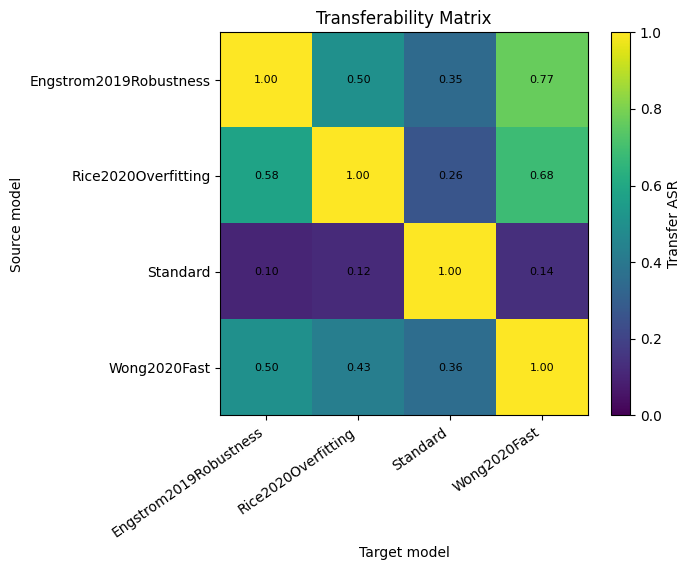

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\transferability_matrix.png


In [77]:
def plot_matrix(df_matrix, title, output_name, value_label="value"):
    if df_matrix is None:
        print("No matrix data to plot.")
        return

    source_col = df_matrix.columns[0]
    matrix = df_matrix.set_index(source_col)

    fig, ax = plt.subplots(figsize=(7, 5.8))
    im = ax.imshow(matrix.values.astype(float), vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_xticklabels(matrix.columns, rotation=35, ha="right")
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Target model")
    ax.set_ylabel("Source model")
    ax.set_title(title)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix.values[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, label=value_label)
    plt.tight_layout()
    out = FIG_DIR / output_name
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


plot_matrix(
    transfer_matrix_df,
    title="Transferability Matrix",
    output_name="transferability_matrix.png",
    value_label="Transfer ASR",
)

## 16. Layer-wise CKA plots

Layer-wise CKA uses only matched depth: `source_layer == target_layer`.

,source_model,target_model,layer,cka
144,Engstrom2019Robustness,Rice2020Overfitting,1,0.992231
151,Engstrom2019Robustness,Rice2020Overfitting,2,0.956456
158,Engstrom2019Robustness,Rice2020Overfitting,3,0.830960
165,Engstrom2019Robustness,Rice2020Overfitting,4,0.756643
172,Engstrom2019Robustness,Rice2020Overfitting,5,0.711403


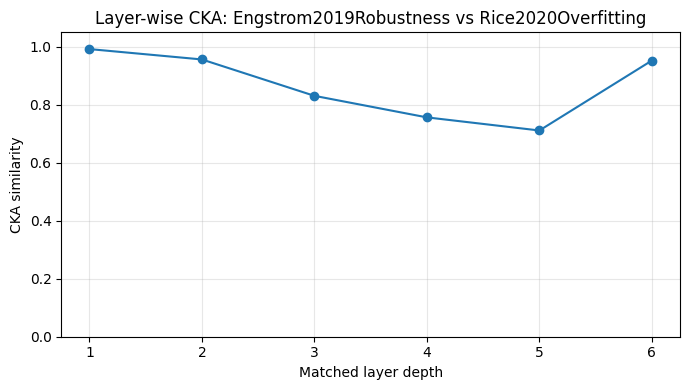

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\layerwise_cka_Engstrom2019Robustness_vs_Rice2020Overfitting.png


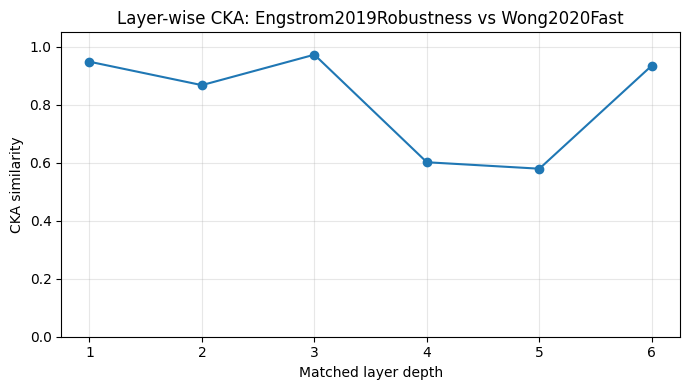

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\layerwise_cka_Engstrom2019Robustness_vs_Wong2020Fast.png


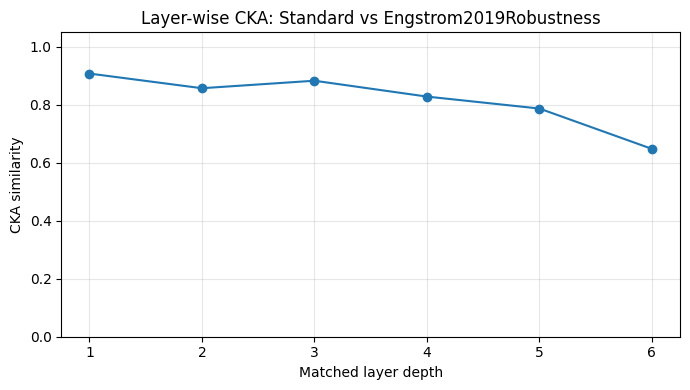

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\layerwise_cka_Standard_vs_Engstrom2019Robustness.png


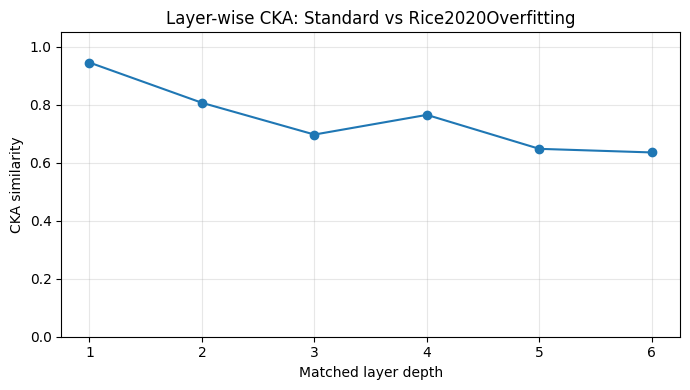

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\layerwise_cka_Standard_vs_Rice2020Overfitting.png


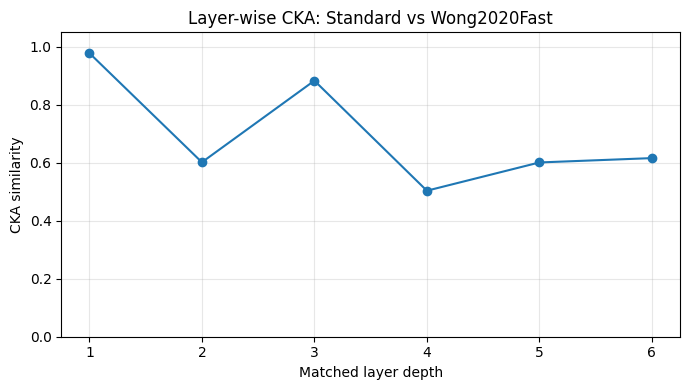

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\layerwise_cka_Standard_vs_Wong2020Fast.png


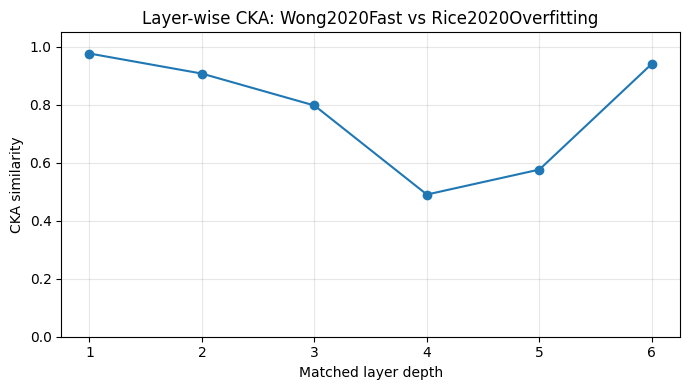

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\layerwise_cka_Wong2020Fast_vs_Rice2020Overfitting.png


In [78]:
def get_layerwise_cka(cka_df):
    required = {"source_model", "target_model", "source_layer", "target_layer", "cka"}
    missing = required - set(cka_df.columns)
    if missing:
        raise ValueError(f"Missing columns in CKA dataframe: {missing}")

    layerwise = cka_df[cka_df["source_layer"] == cka_df["target_layer"]].copy()
    layerwise = layerwise.rename(columns={"source_layer": "layer"})
    return layerwise[["source_model", "target_model", "layer", "cka"]].sort_values(
        ["source_model", "target_model", "layer"]
    )


def plot_layerwise_cka(layerwise_cka_df):
    if layerwise_cka_df is None or layerwise_cka_df.empty:
        print("No layer-wise CKA data to plot.")
        return

    for (src, tgt), group in layerwise_cka_df.groupby(["source_model", "target_model"]):
        group = group.sort_values("layer")
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(group["layer"], group["cka"], marker="o")
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Matched layer depth")
        ax.set_ylabel("CKA similarity")
        ax.set_title(f"Layer-wise CKA: {src} vs {tgt}")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        out = FIG_DIR / f"layerwise_cka_{safe_model_name(src)}_vs_{safe_model_name(tgt)}.png"
        plt.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", out)


if cka_df is not None:
    layerwise_cka_df = get_layerwise_cka(cka_df)
    display(layerwise_cka_df.head())
    plot_layerwise_cka(layerwise_cka_df)
else:
    layerwise_cka_df = None

## 17. Cross-layer CKA heatmaps

Cross-layer CKA uses the full source-layer × target-layer matrix.

In [79]:
def plot_cross_layer_cka(cka_df, source_model, target_model):
    pair = cka_df[
        (cka_df["source_model"] == source_model) &
        (cka_df["target_model"] == target_model)
    ].copy()

    if pair.empty:
        print(f"No CKA data for {source_model} -> {target_model}")
        return

    # Rows = source layers, Columns = target layers
    # Sorted ascending so layer 1 is first
    matrix = (
        pair.pivot(index="source_layer", columns="target_layer", values="cka")
        .sort_index()
        .sort_index(axis=1)
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    # origin="lower" makes layer 1 appear at the bottom
    im = ax.imshow(
        matrix.values,
        vmin=0,
        vmax=1,
        aspect="auto",
        origin="lower"
    )

    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_yticks(np.arange(matrix.shape[0]))

    ax.set_xticklabels(matrix.columns)
    ax.set_yticklabels(matrix.index)

    ax.set_xlabel(f"{target_model} layer")
    ax.set_ylabel(f"{source_model} layer")
    ax.set_title(f"Cross-layer CKA: {source_model} vs {target_model}")

    # Add values inside cells
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix.values[i, j]
            if pd.notna(val):
                ax.text(
                    j,
                    i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    fig.colorbar(im, ax=ax, label="CKA")
    plt.tight_layout()

    out = FIG_DIR / f"cross_layer_cka_{safe_model_name(source_model)}_vs_{safe_model_name(target_model)}.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()

    print("Saved:", out)


if cka_df is not None:
    model_pairs = cka_df[["source_model", "target_model"]].drop_duplicates()
    display(model_pairs)
    for _, row in model_pairs.iterrows():
        plot_cross_layer_cka(cka_df, row["source_model"], row["target_model"])
else:
    print("No CKA dataframe available for cross-layer plotting.")


## 18. Pairwise summary table

This combines CKA, SAT, and transferability into one interpretable table.

In [ ]:
def build_pairwise_summary(cka_df=None, sat_df=None, transfer_long_df=None, model_info_df=None):
    summary = None

    if cka_df is not None:
        same_layer = cka_df[cka_df["source_layer"] == cka_df["target_layer"]].copy()
        cka_summary = same_layer.groupby(["source_model", "target_model"], as_index=False).agg(
            mean_layerwise_cka=("cka", "mean"),
            min_layerwise_cka=("cka", "min"),
            max_layerwise_cka=("cka", "max"),
        )
        summary = cka_summary

    if sat_df is not None:
        summary = sat_df if summary is None else summary.merge(sat_df, on=["source_model", "target_model"], how="outer")

    if transfer_long_df is not None:
        transfer_cols = ["source_model", "target_model", "transfer_asr"]
        summary = transfer_long_df[transfer_cols] if summary is None else summary.merge(transfer_long_df[transfer_cols], on=["source_model", "target_model"], how="outer")

    if summary is None:
        return None

    if model_info_df is not None and "model" in model_info_df.columns:
        info_cols = [c for c in ["model", "architecture", "training_type"] if c in model_info_df.columns]
        source_info = model_info_df[info_cols].rename(columns={
            "model": "source_model",
            "architecture": "source_architecture",
            "training_type": "source_training_type",
        })
        target_info = model_info_df[info_cols].rename(columns={
            "model": "target_model",
            "architecture": "target_architecture",
            "training_type": "target_training_type",
        })
        summary = summary.merge(source_info, on="source_model", how="left")
        summary = summary.merge(target_info, on="target_model", how="left")

    return summary


pairwise_summary_df = build_pairwise_summary(
    cka_df=cka_df,
    sat_df=sat_df,
    transfer_long_df=transfer_long_df,
    model_info_df=model_info_df,
)

if pairwise_summary_df is not None:
    pairwise_summary_path = SAVED_DIR / "pairwise_summary.csv"
    pairwise_summary_df.to_csv(pairwise_summary_path, index=False)
    display(pairwise_summary_df)
    print("Saved:", pairwise_summary_path)
else:
    print("No summary available.")

,source_model,target_model,mean_layerwise_cka,min_layerwise_cka,max_layerwise_cka,sat,gaas,gaas_std,transfer_asr,source_architecture,source_training_type,target_architecture,target_training_type
0,Engstrom2019Robustness,Engstrom2019Robustness,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,ResNet,adversarial_training,ResNet,adversarial_training
1,Engstrom2019Robustness,Rice2020Overfitting,0.866735,0.711403,0.992231,0.500000,0.668362,0.122353,0.500000,ResNet,adversarial_training,WideResNet,adversarial_training_robust_overfitting
2,Engstrom2019Robustness,Standard,NaN,NaN,NaN,0.346154,NaN,NaN,0.346154,ResNet,adversarial_training,ResNet,standard
3,Engstrom2019Robustness,Wong2020Fast,0.817728,0.579593,0.972941,0.769231,0.615518,0.109131,0.769231,ResNet,adversarial_training,WideResNet,fast_adversarial_training
4,Rice2020Overfitting,Engstrom2019Robustness,NaN,NaN,NaN,0.578947,NaN,NaN,0.578947,WideResNet,adversarial_training_robust_overfitting,ResNet,adversarial_training
5,Rice2020Overfitting,Rice2020Overfitting,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,WideResNet,adversarial_training_robust_overfitting,WideResNet,adversarial_training_robust_overfitting
6,Rice2020Overfitting,Standard,NaN,NaN,NaN,0.263158,NaN,NaN,0.263158,WideResNet,adversarial_training_robust_overfitting,ResNet,standard
7,Rice2020Overfitting,Wong2020Fast,NaN,NaN,NaN,0.684211,NaN,NaN,0.684211,WideResNet,adversarial_training_robust_overfitting,WideResNet,fast_adversarial_training
8,Standard,Engstrom2019Robustness,0.818598,0.648022,0.907789,0.101695,0.018267,0.022775,0.101695,ResNet,standard,ResNet,adversarial_training
9,Standard,Rice2020Overfitting,0.749871,0.635652,0.945875,0.118644,0.018081,0.024425,0.118644,ResNet,standard,WideResNet,adversarial_training_robust_overfitting


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\pairwise_summary.csv


## 19. Correlation analysis: CKA similarity vs transferability

This section estimates whether layer-wise CKA similarity is associated with adversarial transferability.

For each model pair and each matched layer, we compare:

- `S_l`: CKA similarity at layer `l`
- `T`: transfer attack success rate from source model to target model

In [81]:
def prepare_correlation_dataframe(cka_df, transfer_long_df):
    if cka_df is None or transfer_long_df is None:
        return None

    layerwise = cka_df[cka_df["source_layer"] == cka_df["target_layer"]].copy()
    layerwise = layerwise.rename(columns={
        "source_layer": "layer_idx",
        "cka": "S_ell",
    })

    layerwise = layerwise[["source_model", "target_model", "layer_idx", "S_ell"]]
    transfer = transfer_long_df[["source_model", "target_model", "transfer_asr"]].copy()
    transfer = transfer.rename(columns={"transfer_asr": "T"})

    corr_df = layerwise.merge(transfer, on=["source_model", "target_model"], how="inner")
    return corr_df


def compute_layer_correlations(corr_df, method="pearson"):
    if corr_df is None or corr_df.empty:
        return None

    rows = []
    for layer_idx, group in corr_df.groupby("layer_idx"):
        s_vals = group["S_ell"].astype(float).values
        t_vals = group["T"].astype(float).values

        valid = np.isfinite(s_vals) & np.isfinite(t_vals)
        s_vals = s_vals[valid]
        t_vals = t_vals[valid]

        if len(s_vals) < 2 or np.var(s_vals) < 1e-12 or np.var(t_vals) < 1e-12:
            rho, p_value = np.nan, np.nan
        elif HAS_SCIPY:
            stat = pearsonr(s_vals, t_vals) if method == "pearson" else spearmanr(s_vals, t_vals)
            rho = float(stat.statistic if hasattr(stat, "statistic") else stat[0])
            p_value = float(stat.pvalue if hasattr(stat, "pvalue") else stat[1])
        else:
            rho = float(np.corrcoef(s_vals, t_vals)[0, 1])
            p_value = np.nan

        rows.append({
            "layer_idx": int(layer_idx),
            "rho": rho,
            "p_value": p_value,
            "n_obs": int(len(s_vals)),
            "method": method,
        })

    return pd.DataFrame(rows).sort_values("layer_idx").reset_index(drop=True)


corr_input_df = prepare_correlation_dataframe(cka_df, transfer_long_df)
rho_df = compute_layer_correlations(corr_input_df, method="pearson")

if corr_input_df is not None:
    corr_input_path = SAVED_DIR / "cka_transfer_correlation_input.csv"
    corr_input_df.to_csv(corr_input_path, index=False)
    display(corr_input_df.head())
    print("Saved:", corr_input_path)

if rho_df is not None:
    rho_path = SAVED_DIR / "cka_transfer_layer_correlations.csv"
    rho_df.to_csv(rho_path, index=False)
    display(rho_df)
    print("Saved:", rho_path)
else:
    print("Correlation analysis could not be computed.")

,source_model,target_model,layer_idx,S_ell,T
0,Standard,Engstrom2019Robustness,1,0.907789,0.101695
1,Standard,Engstrom2019Robustness,2,0.857204,0.101695
2,Standard,Engstrom2019Robustness,3,0.883070,0.101695
3,Standard,Engstrom2019Robustness,4,0.828382,0.101695
4,Standard,Engstrom2019Robustness,5,0.787123,0.101695


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\cka_transfer_correlation_input.csv


,layer_idx,rho,p_value,n_obs,method
0,1,0.329773,0.523272,6,pearson
1,2,0.529006,0.280511,6,pearson
2,3,0.509787,0.301562,6,pearson
3,4,-0.285343,0.583602,6,pearson
4,5,-0.433032,0.391053,6,pearson
5,6,0.893498,0.016410,6,pearson


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\cka_transfer_layer_correlations.csv


## 20. Plot correlation profile

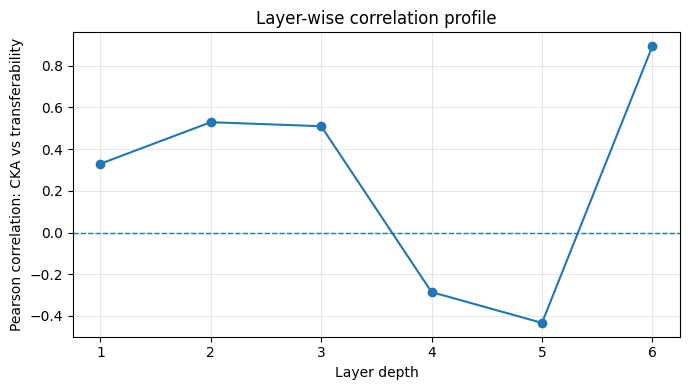

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\cka_transfer_correlation_profile.png


In [82]:
def plot_correlation_profile(rho_df):
    if rho_df is None or rho_df.empty:
        print("No correlation results to plot.")
        return

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(rho_df["layer_idx"], rho_df["rho"], marker="o")
    ax.axhline(0, linewidth=1, linestyle="--")
    ax.set_xlabel("Layer depth")
    ax.set_ylabel("Pearson correlation: CKA vs transferability")
    ax.set_title("Layer-wise correlation profile")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    out = FIG_DIR / "cka_transfer_correlation_profile.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


plot_correlation_profile(rho_df)

## 21. Full CKA representation analysis

This section makes the CKA part stronger and more complete.

It adds four extra outputs:

1. **Early / middle / late CKA groups**  
   This avoids the weak claim that “early layers are similar and later layers differ.”

2. **Correlation between each CKA group and transferability**  
   This checks which representation level is most related to adversarial transfer.

3. **Cross-layer best-match and layer-shift analysis**  
   This checks whether similar features appear at shifted depths across models.

4. **Pair-type summaries**  
   This compares robust–robust pairs against standard–robust pairs.


In [83]:
def make_ordered_cka_for_transfer(cka_df):
    """Return CKA rows in both source->target directions.

    CKA itself is symmetric, but transferability is directional. If the CKA
    computation used unique pairs only, this function duplicates each pair in
    the reverse direction so it can be merged with A->B and B->A transfer rows.
    """
    if cka_df is None or cka_df.empty:
        return None

    base = cka_df.copy()
    reverse = base.rename(columns={
        "source_model": "target_model",
        "target_model": "source_model",
        "source_layer": "target_layer",
        "target_layer": "source_layer",
        "source_layer_name": "target_layer_name",
        "target_layer_name": "source_layer_name",
    }).copy()

    # After rename, columns are duplicated semantically but pandas keeps the new names.
    # Reorder them back to the original structure.
    reverse = reverse[base.columns]

    ordered = pd.concat([base, reverse], ignore_index=True)
    ordered = ordered.drop_duplicates(
        subset=["source_model", "target_model", "source_layer", "target_layer"],
        keep="first"
    )
    return ordered


def layer_group_from_index(layer_idx, max_layer_idx):
    """Map a layer index to early/middle/late using relative depth."""
    if max_layer_idx <= 1:
        return "all"

    relative_depth = (layer_idx - 1) / (max_layer_idx - 1)
    if relative_depth < 1/3:
        return "early"
    if relative_depth < 2/3:
        return "middle"
    return "late"


def add_model_pair_type(df, model_info_df):
    """Add source/target training types and pair category."""
    if df is None or df.empty or model_info_df is None:
        return df

    info = model_info_df[["model", "training_type"]].copy()
    out = df.merge(
        info.rename(columns={"model": "source_model", "training_type": "source_training_type"}),
        on="source_model",
        how="left"
    )
    out = out.merge(
        info.rename(columns={"model": "target_model", "training_type": "target_training_type"}),
        on="target_model",
        how="left"
    )

    def is_standard(t):
        return str(t).lower() == "standard"

    def pair_type(row):
        s_std = is_standard(row.get("source_training_type"))
        t_std = is_standard(row.get("target_training_type"))
        if s_std and t_std:
            return "standard_standard"
        if (not s_std) and (not t_std):
            return "robust_robust"
        return "standard_robust"

    out["pair_type"] = out.apply(pair_type, axis=1)
    return out


def build_layer_group_cka_table(cka_df, transfer_long_df=None, model_info_df=None):
    """Compute early/middle/late same-layer CKA for every ordered model pair."""
    ordered_cka = make_ordered_cka_for_transfer(cka_df)
    if ordered_cka is None:
        return None, None

    same = ordered_cka[ordered_cka["source_layer"] == ordered_cka["target_layer"]].copy()
    if same.empty:
        return None, None

    # Each model pair can have a different number of selected layers.
    max_layers = same.groupby(["source_model", "target_model"])["source_layer"].transform("max")
    same["layer_group"] = [
        layer_group_from_index(int(layer), int(max_layer))
        for layer, max_layer in zip(same["source_layer"], max_layers)
    ]

    long_summary = same.groupby(
        ["source_model", "target_model", "layer_group"],
        as_index=False
    ).agg(
        mean_cka=("cka", "mean"),
        min_cka=("cka", "min"),
        max_cka=("cka", "max"),
        std_cka=("cka", "std"),
        n_layers=("cka", "count"),
    )

    wide = long_summary.pivot_table(
        index=["source_model", "target_model"],
        columns="layer_group",
        values="mean_cka",
        aggfunc="mean"
    ).reset_index()

    # Standardize column names.
    for col in ["early", "middle", "late", "all"]:
        if col in wide.columns:
            wide = wide.rename(columns={col: f"{col}_cka"})

    # Add overall same-layer CKA.
    overall = same.groupby(["source_model", "target_model"], as_index=False).agg(
        mean_layerwise_cka=("cka", "mean"),
        min_layerwise_cka=("cka", "min"),
        max_layerwise_cka=("cka", "max"),
    )
    wide = wide.merge(overall, on=["source_model", "target_model"], how="left")

    if transfer_long_df is not None:
        transfer_cols = ["source_model", "target_model", "transfer_asr"]
        if set(transfer_cols).issubset(transfer_long_df.columns):
            wide = wide.merge(transfer_long_df[transfer_cols], on=["source_model", "target_model"], how="left")

    wide = add_model_pair_type(wide, model_info_df)
    long_summary = add_model_pair_type(long_summary, model_info_df)
    return long_summary, wide


layer_group_cka_long_df, layer_group_cka_summary_df = build_layer_group_cka_table(
    cka_df=cka_df,
    transfer_long_df=transfer_long_df,
    model_info_df=model_info_df,
)

if layer_group_cka_long_df is not None:
    path = SAVED_DIR / "cka_layer_group_long.csv"
    layer_group_cka_long_df.to_csv(path, index=False)
    display(layer_group_cka_long_df.head())
    print("Saved:", path)

if layer_group_cka_summary_df is not None:
    path = SAVED_DIR / "cka_layer_group_summary.csv"
    layer_group_cka_summary_df.to_csv(path, index=False)
    display(layer_group_cka_summary_df)
    print("Saved:", path)
else:
    print("Layer-group CKA summary could not be computed.")


,source_model,target_model,layer_group,mean_cka,min_cka,max_cka,std_cka,n_layers,source_training_type,target_training_type,pair_type
0,Engstrom2019Robustness,Rice2020Overfitting,early,0.974344,0.956456,0.992231,0.025297,2,adversarial_training,adversarial_training_robust_overfitting,robust_robust
1,Engstrom2019Robustness,Rice2020Overfitting,late,0.832060,0.711403,0.952716,0.170634,2,adversarial_training,adversarial_training_robust_overfitting,robust_robust
2,Engstrom2019Robustness,Rice2020Overfitting,middle,0.793801,0.756643,0.830960,0.052550,2,adversarial_training,adversarial_training_robust_overfitting,robust_robust
3,Engstrom2019Robustness,Standard,early,0.882497,0.857204,0.907789,0.035768,2,adversarial_training,standard,standard_robust
4,Engstrom2019Robustness,Standard,late,0.717572,0.648022,0.787123,0.098359,2,adversarial_training,standard,standard_robust


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\cka_layer_group_long.csv


,source_model,target_model,early_cka,late_cka,middle_cka,mean_layerwise_cka,min_layerwise_cka,max_layerwise_cka,transfer_asr,source_training_type,target_training_type,pair_type
0,Engstrom2019Robustness,Rice2020Overfitting,0.974344,0.832060,0.793801,0.866735,0.711403,0.992231,0.500000,adversarial_training,adversarial_training_robust_overfitting,robust_robust
1,Engstrom2019Robustness,Standard,0.882497,0.717572,0.855726,0.818598,0.648022,0.907789,0.346154,adversarial_training,standard,standard_robust
2,Engstrom2019Robustness,Wong2020Fast,0.908258,0.757531,0.787396,0.817728,0.579593,0.972941,0.769231,adversarial_training,fast_adversarial_training,robust_robust
3,Rice2020Overfitting,Engstrom2019Robustness,0.974344,0.832060,0.793801,0.866735,0.711403,0.992231,0.578947,adversarial_training_robust_overfitting,adversarial_training,robust_robust
4,Rice2020Overfitting,Standard,0.876429,0.641869,0.731314,0.749871,0.635652,0.945875,0.263158,adversarial_training_robust_overfitting,standard,standard_robust
5,Rice2020Overfitting,Wong2020Fast,0.942313,0.759060,0.644072,0.781815,0.490477,0.976967,0.684211,adversarial_training_robust_overfitting,fast_adversarial_training,robust_robust
6,Standard,Engstrom2019Robustness,0.882497,0.717572,0.855726,0.818598,0.648022,0.907789,0.101695,standard,adversarial_training,standard_robust
7,Standard,Rice2020Overfitting,0.876429,0.641869,0.731314,0.749871,0.635652,0.945875,0.118644,standard,adversarial_training_robust_overfitting,standard_robust
8,Standard,Wong2020Fast,0.790059,0.608630,0.693487,0.697392,0.503674,0.978289,0.135593,standard,fast_adversarial_training,standard_robust
9,Wong2020Fast,Engstrom2019Robustness,0.908258,0.757531,0.787396,0.817728,0.579593,0.972941,0.500000,fast_adversarial_training,adversarial_training,robust_robust


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\cka_layer_group_summary.csv


## 22. CKA group correlation with transferability

 this checks whether **early, middle, or late representation similarity** is more connected to **adversarial transferability**.


,cka_feature,rho,p_value,n_obs,method
0,early_cka,0.597374,0.040258,12,pearson
1,late_cka,0.677645,0.015459,12,pearson
2,mean_layerwise_cka,0.488227,0.107311,12,pearson
3,middle_cka,-0.087356,0.787195,12,pearson


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\cka_group_transfer_correlations.csv


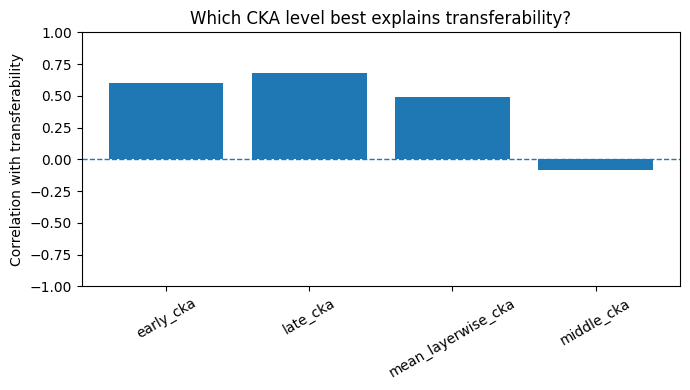

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\cka_group_transfer_correlations.png


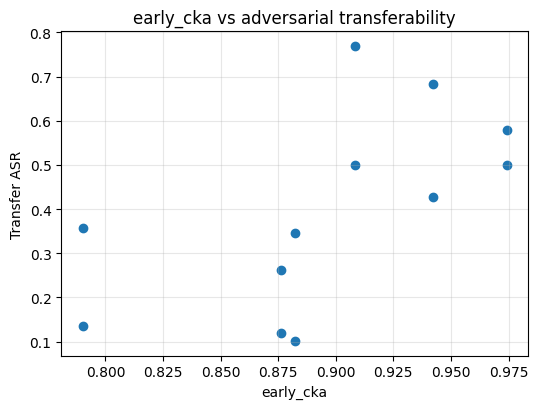

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\early_cka_vs_transferability.png


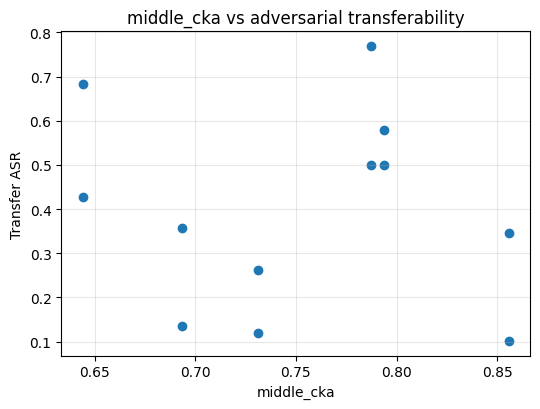

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\middle_cka_vs_transferability.png


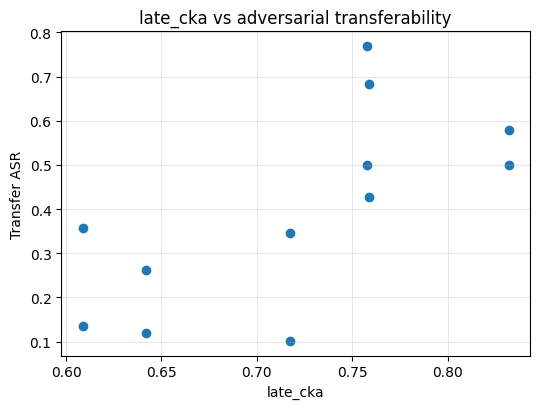

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\late_cka_vs_transferability.png


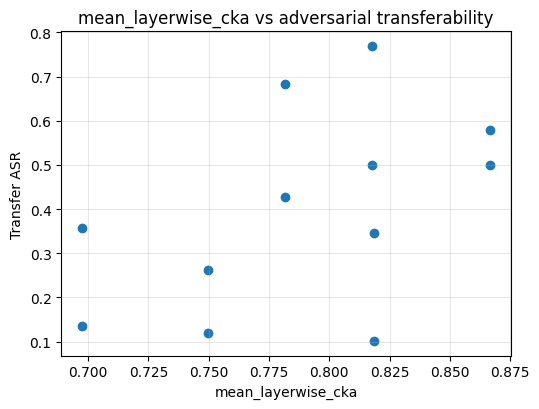

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\mean_layerwise_cka_vs_transferability.png


In [84]:
def compute_group_transfer_correlations(layer_group_cka_summary_df, method="pearson"):
    if layer_group_cka_summary_df is None or layer_group_cka_summary_df.empty:
        return None

    group_cols = [
        c for c in ["early_cka", "middle_cka", "late_cka", "all_cka", "mean_layerwise_cka"]
        if c in layer_group_cka_summary_df.columns
    ]
    if "transfer_asr" not in layer_group_cka_summary_df.columns:
        print("transfer_asr column is missing.")
        return None

    rows = []
    for col in group_cols:
        tmp = layer_group_cka_summary_df[[col, "transfer_asr"]].copy()
        tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()
        x = tmp[col].astype(float).values
        y = tmp["transfer_asr"].astype(float).values

        if len(x) < 2 or np.var(x) < 1e-12 or np.var(y) < 1e-12:
            rho, p_value = np.nan, np.nan
        elif HAS_SCIPY:
            stat = pearsonr(x, y) if method == "pearson" else spearmanr(x, y)
            rho = float(stat.statistic if hasattr(stat, "statistic") else stat[0])
            p_value = float(stat.pvalue if hasattr(stat, "pvalue") else stat[1])
        else:
            rho = float(np.corrcoef(x, y)[0, 1])
            p_value = np.nan

        rows.append({
            "cka_feature": col,
            "rho": rho,
            "p_value": p_value,
            "n_obs": int(len(x)),
            "method": method,
        })

    return pd.DataFrame(rows).sort_values("cka_feature").reset_index(drop=True)


def plot_group_transfer_correlations(group_corr_df):
    if group_corr_df is None or group_corr_df.empty:
        print("No group correlation data to plot.")
        return

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(group_corr_df["cka_feature"], group_corr_df["rho"])
    ax.axhline(0, linewidth=1, linestyle="--")
    ax.set_ylim(-1, 1)
    ax.set_ylabel("Correlation with transferability")
    ax.set_title("Which CKA level best explains transferability?")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()

    out = FIG_DIR / "cka_group_transfer_correlations.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


def plot_group_transfer_scatters(layer_group_cka_summary_df):
    if layer_group_cka_summary_df is None or layer_group_cka_summary_df.empty:
        print("No layer-group summary data to plot.")
        return

    group_cols = [c for c in ["early_cka", "middle_cka", "late_cka", "mean_layerwise_cka"] if c in layer_group_cka_summary_df.columns]
    if "transfer_asr" not in layer_group_cka_summary_df.columns:
        print("transfer_asr column is missing.")
        return

    for col in group_cols:
        tmp = layer_group_cka_summary_df[[col, "transfer_asr", "source_model", "target_model"]].replace([np.inf, -np.inf], np.nan).dropna()
        if tmp.empty:
            continue

        fig, ax = plt.subplots(figsize=(5.5, 4.2))
        ax.scatter(tmp[col], tmp["transfer_asr"])
        ax.set_xlabel(col)
        ax.set_ylabel("Transfer ASR")
        ax.set_title(f"{col} vs adversarial transferability")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        out = FIG_DIR / f"{col}_vs_transferability.png"
        plt.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", out)


group_corr_df = compute_group_transfer_correlations(layer_group_cka_summary_df, method="pearson")

if group_corr_df is not None:
    path = SAVED_DIR / "cka_group_transfer_correlations.csv"
    group_corr_df.to_csv(path, index=False)
    display(group_corr_df)
    print("Saved:", path)

plot_group_transfer_correlations(group_corr_df)
plot_group_transfer_scatters(layer_group_cka_summary_df)


## 23. Cross-layer CKA shift analysis

Cross-layer CKA becomes more useful when we measure **where the best match happens**.



,source_model,target_model,source_layer,best_target_layer,source_layer_name,best_target_layer_name,best_cka,layer_shift,abs_layer_shift,source_training_type,target_training_type,pair_type
0,Engstrom2019Robustness,Rice2020Overfitting,1,1,conv1,conv1,0.992231,0,0,adversarial_training,adversarial_training_robust_overfitting,robust_robust
1,Engstrom2019Robustness,Rice2020Overfitting,2,2,layer2.0.conv1,block1.layer.2.conv2,0.956456,0,0,adversarial_training,adversarial_training_robust_overfitting,robust_robust
2,Engstrom2019Robustness,Rice2020Overfitting,3,2,layer2.3.conv1,block1.layer.2.conv2,0.934610,-1,1,adversarial_training,adversarial_training_robust_overfitting,robust_robust
3,Engstrom2019Robustness,Rice2020Overfitting,4,2,layer3.2.conv2,block1.layer.2.conv2,0.830911,-2,2,adversarial_training,adversarial_training_robust_overfitting,robust_robust
4,Engstrom2019Robustness,Rice2020Overfitting,5,5,layer3.5.conv3,block3.layer.1.conv2,0.711403,0,0,adversarial_training,adversarial_training_robust_overfitting,robust_robust


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\cross_layer_cka_best_matches.csv


,source_model,target_model,mean_cross_layer_cka,max_cross_layer_cka,mean_diagonal_cka,mean_off_diagonal_cka,mean_near_diagonal_cka,mean_best_match_cka,mean_abs_best_layer_shift,max_abs_best_layer_shift,n_source_layers,transfer_asr,source_training_type,target_training_type,pair_type
0,Engstrom2019Robustness,Rice2020Overfitting,0.651091,0.992231,0.866735,0.607962,0.768625,0.896388,0.500000,2,6,0.500000,adversarial_training,adversarial_training_robust_overfitting,robust_robust
1,Engstrom2019Robustness,Standard,0.624130,0.907789,0.818598,0.585237,0.744794,0.821621,0.333333,1,6,0.346154,adversarial_training,standard,standard_robust
2,Engstrom2019Robustness,Wong2020Fast,0.654162,0.972941,0.817728,0.621449,0.767422,0.900467,0.666667,2,6,0.769231,adversarial_training,fast_adversarial_training,robust_robust
3,Rice2020Overfitting,Engstrom2019Robustness,0.651091,0.992231,0.866735,0.607962,0.768625,0.891157,0.666667,2,6,0.578947,adversarial_training_robust_overfitting,adversarial_training,robust_robust
4,Rice2020Overfitting,Standard,0.599562,0.945875,0.749871,0.569501,0.683387,0.815354,0.833333,2,6,0.263158,adversarial_training_robust_overfitting,standard,standard_robust
5,Rice2020Overfitting,Wong2020Fast,0.679066,0.976967,0.781815,0.658516,0.777947,0.893784,0.833333,2,6,0.684211,adversarial_training_robust_overfitting,fast_adversarial_training,robust_robust
6,Standard,Engstrom2019Robustness,0.624130,0.907789,0.818598,0.585237,0.744794,0.826114,0.166667,1,6,0.101695,standard,adversarial_training,standard_robust
7,Standard,Rice2020Overfitting,0.599562,0.945875,0.749871,0.569501,0.683387,0.786273,1.000000,3,6,0.118644,standard,adversarial_training_robust_overfitting,standard_robust
8,Standard,Wong2020Fast,0.583867,0.978289,0.697392,0.561162,0.671484,0.815415,0.666667,2,6,0.135593,standard,fast_adversarial_training,standard_robust
9,Wong2020Fast,Engstrom2019Robustness,0.654162,0.972941,0.817728,0.621449,0.767422,0.915800,0.833333,3,6,0.500000,fast_adversarial_training,adversarial_training,robust_robust


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\cross_layer_cka_shift_summary.csv


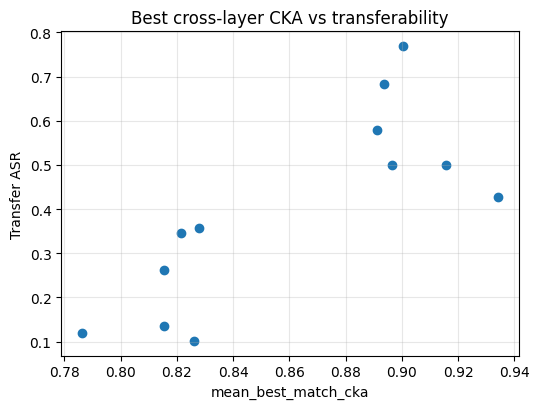

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\mean_best_match_cka_vs_transferability.png


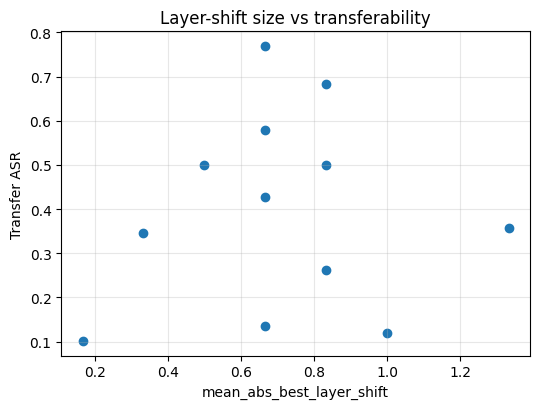

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\mean_abs_best_layer_shift_vs_transferability.png


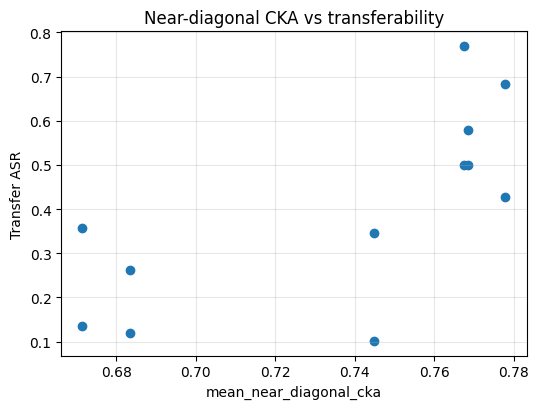

Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\figures\mean_near_diagonal_cka_vs_transferability.png


In [ ]:
def build_cross_layer_shift_analysis(cka_df, transfer_long_df=None, model_info_df=None):
    ordered_cka = make_ordered_cka_for_transfer(cka_df)

    if ordered_cka is None or ordered_cka.empty:
        print("No ordered CKA data available.")
        return None, None

    best_rows = []
    summary_rows = []

    for (src, tgt), pair in ordered_cka.groupby(["source_model", "target_model"]):
        pair = pair.copy()

        # Make sure CKA is numeric.
        pair["cka"] = pd.to_numeric(pair["cka"], errors="coerce")

        # Remove rows where CKA is NaN.
        pair_valid = pair.dropna(subset=["cka"]).copy()

        # If this model pair has only NaN values, skip it safely.
        if pair_valid.empty:
            print(f"Skipping {src} -> {tgt}: all CKA values are NaN.")
            continue

        pair_valid["is_diagonal"] = pair_valid["source_layer"] == pair_valid["target_layer"]
        pair_valid["layer_shift"] = pair_valid["target_layer"] - pair_valid["source_layer"]
        pair_valid["abs_layer_shift"] = pair_valid["layer_shift"].abs()
        pair_valid["is_near_diagonal"] = pair_valid["abs_layer_shift"] <= 1

        # Best target layer for every source layer.
        # This is now safe because NaN-only groups were removed.
        idx = pair_valid.groupby("source_layer")["cka"].idxmax()
        best = pair_valid.loc[idx].copy()

        best = best[[
            "source_model", "target_model",
            "source_layer", "target_layer",
            "source_layer_name", "target_layer_name",
            "cka", "layer_shift", "abs_layer_shift"
        ]].rename(columns={
            "target_layer": "best_target_layer",
            "target_layer_name": "best_target_layer_name",
            "cka": "best_cka",
        })

        best_rows.append(best)

        diag = pair_valid[pair_valid["is_diagonal"]]
        offdiag = pair_valid[~pair_valid["is_diagonal"]]
        near_diag = pair_valid[pair_valid["is_near_diagonal"]]

        summary_rows.append({
            "source_model": src,
            "target_model": tgt,
            "mean_cross_layer_cka": pair_valid["cka"].mean(),
            "max_cross_layer_cka": pair_valid["cka"].max(),
            "mean_diagonal_cka": diag["cka"].mean() if not diag.empty else np.nan,
            "mean_off_diagonal_cka": offdiag["cka"].mean() if not offdiag.empty else np.nan,
            "mean_near_diagonal_cka": near_diag["cka"].mean() if not near_diag.empty else np.nan,
            "mean_best_match_cka": best["best_cka"].mean(),
            "mean_abs_best_layer_shift": best["abs_layer_shift"].mean(),
            "max_abs_best_layer_shift": best["abs_layer_shift"].max(),
            "n_source_layers": best["source_layer"].nunique(),
            "n_valid_cka_values": len(pair_valid),
            "n_nan_cka_values": pair["cka"].isna().sum(),
        })

    best_matches_df = pd.concat(best_rows, ignore_index=True) if best_rows else None
    cross_summary_df = pd.DataFrame(summary_rows) if summary_rows else None

    if cross_summary_df is None or cross_summary_df.empty:
        print("No valid cross-layer CKA summary could be created.")
        return best_matches_df, cross_summary_df

    if transfer_long_df is not None and "transfer_asr" in transfer_long_df.columns:
        cross_summary_df = cross_summary_df.merge(
            transfer_long_df[["source_model", "target_model", "transfer_asr"]],
            on=["source_model", "target_model"],
            how="left"
        )

    cross_summary_df = add_model_pair_type(cross_summary_df, model_info_df)

    if best_matches_df is not None:
        best_matches_df = add_model_pair_type(best_matches_df, model_info_df)

    return best_matches_df, cross_summary_df


def plot_cross_layer_shift_vs_transfer(cross_layer_summary_df):
    if cross_layer_summary_df is None or cross_layer_summary_df.empty:
        print("No cross-layer summary data to plot.")
        return

    if "transfer_asr" not in cross_layer_summary_df.columns:
        print("transfer_asr column is missing.")
        return

    plot_specs = [
        ("mean_best_match_cka", "Best cross-layer CKA vs transferability"),
        ("mean_abs_best_layer_shift", "Layer-shift size vs transferability"),
        ("mean_near_diagonal_cka", "Near-diagonal CKA vs transferability"),
    ]

    for x_col, title in plot_specs:
        if x_col not in cross_layer_summary_df.columns:
            continue

        tmp = (
            cross_layer_summary_df[[x_col, "transfer_asr"]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if tmp.empty:
            print(f"No valid data to plot for {x_col}.")
            continue

        fig, ax = plt.subplots(figsize=(5.5, 4.2))
        ax.scatter(tmp[x_col], tmp["transfer_asr"])
        ax.set_xlabel(x_col)
        ax.set_ylabel("Transfer ASR")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        out = FIG_DIR / f"{x_col}_vs_transferability.png"
        plt.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", out)


cross_layer_best_matches_df, cross_layer_summary_df = build_cross_layer_shift_analysis(
    cka_df=cka_df,
    transfer_long_df=transfer_long_df,
    model_info_df=model_info_df,
)

if cross_layer_best_matches_df is not None:
    path = SAVED_DIR / "cross_layer_cka_best_matches.csv"
    cross_layer_best_matches_df.to_csv(path, index=False)
    display(cross_layer_best_matches_df.head())
    print("Saved:", path)

if cross_layer_summary_df is not None:
    path = SAVED_DIR / "cross_layer_cka_shift_summary.csv"
    cross_layer_summary_df.to_csv(path, index=False)
    display(cross_layer_summary_df)
    print("Saved:", path)

plot_cross_layer_shift_vs_transfer(cross_layer_summary_df)

## 24. Pair-type summary for CKA interpretation

This table helps answer  question:

> Are robust models more similar to each other than they are to the standard model?




In [86]:
def build_pair_type_cka_summary(layer_group_cka_summary_df, cross_layer_summary_df):
    frames = []

    if layer_group_cka_summary_df is not None and "pair_type" in layer_group_cka_summary_df.columns:
        cols = [c for c in [
            "pair_type", "early_cka", "middle_cka", "late_cka", "mean_layerwise_cka", "transfer_asr"
        ] if c in layer_group_cka_summary_df.columns]
        group_summary = layer_group_cka_summary_df[cols].groupby("pair_type", as_index=False).agg(
            **{f"mean_{c}": (c, "mean") for c in cols if c != "pair_type"},
            n_pairs=("pair_type", "count"),
        )
        group_summary["source_table"] = "layer_group_cka"
        frames.append(group_summary)

    if cross_layer_summary_df is not None and "pair_type" in cross_layer_summary_df.columns:
        cols = [c for c in [
            "pair_type", "mean_cross_layer_cka", "mean_diagonal_cka", "mean_off_diagonal_cka",
            "mean_best_match_cka", "mean_abs_best_layer_shift", "transfer_asr"
        ] if c in cross_layer_summary_df.columns]
        cross_summary = cross_layer_summary_df[cols].groupby("pair_type", as_index=False).agg(
            **{f"mean_{c}": (c, "mean") for c in cols if c != "pair_type"},
            n_pairs=("pair_type", "count"),
        )
        cross_summary["source_table"] = "cross_layer_cka"
        frames.append(cross_summary)

    if not frames:
        return None
    return pd.concat(frames, ignore_index=True, sort=False)


pair_type_cka_summary_df = build_pair_type_cka_summary(layer_group_cka_summary_df, cross_layer_summary_df)

if pair_type_cka_summary_df is not None:
    path = SAVED_DIR / "cka_pair_type_summary.csv"
    pair_type_cka_summary_df.to_csv(path, index=False)
    display(pair_type_cka_summary_df)
    print("Saved:", path)
else:
    print("Pair-type CKA summary could not be computed.")


,pair_type,mean_early_cka,mean_middle_cka,mean_late_cka,mean_mean_layerwise_cka,mean_transfer_asr,n_pairs,source_table,mean_mean_cross_layer_cka,mean_mean_diagonal_cka,mean_mean_off_diagonal_cka,mean_mean_best_match_cka,mean_mean_abs_best_layer_shift
0,robust_robust,0.941638,0.741756,0.782884,0.822093,0.576827,6,layer_group_cka,NaN,NaN,NaN,NaN,NaN
1,standard_robust,0.849661,0.760176,0.656024,0.755287,0.220398,6,layer_group_cka,NaN,NaN,NaN,NaN,NaN
2,robust_robust,NaN,NaN,NaN,NaN,0.576827,6,cross_layer_cka,0.66144,0.822093,0.629309,0.905285,0.694444
3,standard_robust,NaN,NaN,NaN,NaN,0.220398,6,cross_layer_cka,0.60252,0.755287,0.571966,0.815431,0.722222


Saved: c:\Users\hbk-2\OneDrive\Documents\GitHub\MRP-Sem_2-Group_8\saved_outputs\cka_pair_type_summary.csv


## 25. Final file check


In [ ]:
required_files = [
    "model_info.csv",
    "selected_layers.csv",
    "asr_results.csv",
    "transferability_long.csv",
    "transferability_matrix.csv",
    "sat_results.csv",
    "cka_results.csv",
    "pairwise_summary.csv",
    "cka_transfer_layer_correlations.csv",
    "cka_transfer_correlation_input.csv",
    "cka_layer_group_long.csv",
    "cka_layer_group_summary.csv",
    "cka_group_transfer_correlations.csv",
    "cross_layer_cka_best_matches.csv",
    "cross_layer_cka_shift_summary.csv",
    "cka_pair_type_summary.csv",
]

for filename in required_files:
    path = SAVED_DIR / filename
    print(f"{filename:40s} exists = {path.exists()}")

print("\nDone. The notebook is now a single clean pipeline with full CKA representation analysis.")


model_info.csv                           exists = True
selected_layers.csv                      exists = True
asr_results.csv                          exists = True
transferability_long.csv                 exists = True
transferability_matrix.csv               exists = True
sat_results.csv                          exists = True
cka_results.csv                          exists = True
gaas_results.csv                         exists = True
pairwise_summary.csv                     exists = True
cka_transfer_layer_correlations.csv      exists = True
cka_transfer_correlation_input.csv       exists = True
cka_layer_group_long.csv                 exists = True
cka_layer_group_summary.csv              exists = True
cka_group_transfer_correlations.csv      exists = True
cross_layer_cka_best_matches.csv         exists = True
cross_layer_cka_shift_summary.csv        exists = True
cka_pair_type_summary.csv                exists = True

Done. The notebook is now a single clean pipeline with full CKA 